# Validação final — Seoul Bike Sharing 2015–2024

Esta é a etapa confirmatória do projeto. Três candidatos foram congelados pelo notebook 04 sob uma
validação cruzada temporal por ano meteorológico restrita ao regime de operação normal, e aqui cada
um é medido uma única vez sobre o holdout temporal selado, correspondente ao período de dezembro de
2023 até novembro de 2024. Nenhum modelo é retreinado, nenhum hiperparâmetro é tocado e o holdout é
aberto por uma única função auditada, de modo que nenhuma variável do notebook possa carregá-lo para
dentro de uma chamada de modelagem.

Toda a lógica é implementada em `src.final_validation` e `src.final_validation_reports`. O notebook
permanece uma camada fina de apresentação, que declara uma configuração, chama poucas funções
públicas e exibe o que elas retornam.

## 1. Objetivo confirmatório e protocolo pré-registrado

O champion pré-registrado é o `CatBoostRegressor`. O holdout não é apresentado como uma nova busca de
modelos: a regra de decisão é descrita antes de o holdout ser aberto, e ela pode apenas confirmar ou
não confirmar o candidato pré-registrado. O CatBoost é considerado confirmado quando o seu MAE no
holdout é no máximo 1,05 vez o menor MAE entre os três candidatos e, simultaneamente, o seu R² no
holdout é no mínimo o maior R² entre os três menos 0,02. Quando qualquer condição não é satisfeita, o
melhor desempenho no holdout é identificado descritivamente, porém o manifesto do notebook 04 não é
alterado, a busca não é reaberta e nenhum modelo é retreinado.

Duas convenções de sinal opostas são adotadas e explicitadas para evitar interpretação invertida. O
bias é definido como a média de ŷ menos y, de modo que um bias positivo indica superestimação. Já o
resíduo utilizado nos diagnósticos gráficos é definido como y menos ŷ, de modo que um resíduo
positivo indica subestimação.

> ### Insight
>
> A regra de confirmação é pré-registrada antes de o holdout ser aberto, o que preserva o caráter
> confirmatório da etapa. Uma diferença numericamente pequena entre candidatos não é descrita como
> superioridade substantiva, e uma eventual troca definitiva de champion exigiria uma nova janela
> temporal independente.

In [1]:

import os
import sys
import warnings
from pathlib import Path
sys.path.insert(0, os.path.abspath('..'))

from matplotlib import pyplot as plt
from src import final_validation_reports as reports
from src.final_validation import (
    FinalValidationConfig,
    prepare_final_validation,
    run_final_validation,
    run_shap_validation,
)
from src.i18n import make_lang
from src.plotting import set_graph_parameters

set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

lang = make_lang('pt')
config = FinalValidationConfig()

In [2]:
reports.protocol_report(config, lang=lang)

,Item,Valor
0,Champion pré-registrado,CatBoostRegressor
1,Regra de MAE,"MAE do champion ≤ 1,05 × menor MAE entre os três"
2,Regra de R²,"R² do champion ≥ maior R² entre os três − 0,02"
3,Tolerância de MAE (razão),1.05
4,Margem de R²,0.02
5,Decisão se ambas satisfeitas,champion confirmado
6,Decisão caso contrário,champion não confirmado
7,Reabertura da busca,não ocorre; uma nova janela temporal seria nec...


## 2. Ambiente e proveniência

A validação é preparada antes de o holdout ser aberto. O interpretador é verificado, o manifesto dos
candidatos é confrontado com o contrato do notebook 05, os três pipelines congelados têm a sua
proveniência confirmada contra o manifesto e as runs de seleção de origem são auditadas como
concluídas e verificadas. O ambiente e as versões das bibliotecas numericamente relevantes são
registrados para que os resultados sejam reprodutíveis.

In [3]:
plan = prepare_final_validation(config)
reports.provenance_report(plan, lang=lang)

,Item,Valor
0,Ambiente,Bike-Sharing
1,Interpretador,CONDA_PREFIX\py...
2,Versão do Python,3.10.20
3,Fingerprint do ambiente,8f80d9216d47a792
4,Fingerprint do dataset,24f188a95febd94d
5,Fingerprint do regime,1043b392ad5e2806
6,Versão da estratégia de CV,ForwardMeteorologicalYearSplit_v3_normal_opera...
7,Versão do código de seleção,temporal_optimizer_v7
8,Versão do código de validação final,final_validation_v1
9,scikit-learn,1.3.2


## 3. Manifesto dos candidatos congelados

Os três candidatos são exatamente os que o notebook 04 congelou. Cada pipeline carrega um carimbo de
proveniência que reproduz a identidade da run que o selecionou, e o SHA-256 do artefato é registrado
para auditoria. A posição de cada candidato na validação cruzada é apresentada apenas como referência,
sem que nenhuma métrica do holdout seja atribuída às runs de seleção.

In [4]:
reports.candidates_report(plan, lang=lang)

,Papel,Estimator,Run ID de origem,MAE médio (CV),MAE ponderado (CV),R² médio (CV),SHA-256 do artefato,Proveniência confirmada
0,Champion,CatBoostRegressor,2106a5bf79e945f7a4a9d161e2ee01d3,820.401191,840.165428,0.838691,57195bd3badc,True
1,Challenger,HistGradientBoostingRegressor,381e7061d8ef440e917c792ab38e59f3,815.019786,852.950285,0.843872,b27ab507627c,True
2,Challenger,RandomForestRegressor,030ef18ea01d46caacbeb2bc0765da61,847.613928,919.734700,0.831417,3518c691fe7c,True


## 4. Materialização única do holdout

O holdout é aberto uma única vez, depois que todas as invariantes de proveniência foram verificadas. O
fingerprint do desenvolvimento é recalculado e confrontado com o do manifesto, o fingerprint do regime
é recalculado e confrontado, e a janela é exigida com exatamente 8.784 observações horárias. As 744
horas de dezembro de 2024, que existem na fonte mas são posteriores ao holdout, são contadas e
descartadas, nunca devolvidas. Uma reexecução idempotente reutiliza os resultados persistidos em vez
de reabrir o holdout.

In [5]:
results = run_final_validation(config, plan=plan)
reports.holdout_seal_report(results, lang=lang)

,Item,Valor
0,Janela do holdout,None — None
1,Observações no holdout,None
2,Janela de desenvolvimento,carregado do cache
3,Observações de desenvolvimento,None
4,Horas de dez/2024 descartadas,None
5,Fingerprint do dataset,24f188a95febd94d
6,Fingerprint do holdout,None
7,Fingerprint do regime,1043b392ad5e2806
8,Origem dos resultados,resultados reutilizados do cache


## 5. Predições e métricas finais

Cada candidato é predito uma única vez sobre o mesmo holdout, e as predições são finitas, não
negativas e alinhadas às observações. As métricas incluem MAE, RMSE, R², erro absoluto mediano, bias
médio e quantis do erro absoluto. Em vez do MAPE convencional, cuja definição é problemática quando a
demanda contém zeros, é utilizado o WAPE, dado pela soma dos erros absolutos dividida pela soma dos
valores absolutos observados. A diferença de cada métrica em relação à agregação da validação cruzada
também é apresentada.

In [6]:
reports.comparison_report(results, lang=lang)

,Papel,Estimator,Run ID,MAE (holdout),RMSE (holdout),R² (holdout),WAPE (holdout),Erro absoluto mediano,Bias médio (ŷ−y),MAE médio (CV),RMSE médio (CV),R² médio (CV),MAE holdout − CV
0,Champion,CatBoostRegressor,2106a5bf79e945f7a4a9d161e2ee01d3,1118.087076,1605.704072,0.839276,0.230634,768.263229,1000.094704,820.401191,1242.845648,0.838691,297.685885
1,Challenger,HistGradientBoostingRegressor,381e7061d8ef440e917c792ab38e59f3,1424.856938,2069.719454,0.732962,0.293913,893.435660,1278.903696,815.019786,1243.003730,0.843872,609.837151
2,Challenger,RandomForestRegressor,030ef18ea01d46caacbeb2bc0765da61,1593.437122,2322.236136,0.663828,0.328687,987.957226,1407.498130,847.613928,1306.470196,0.831417,745.823194


In [7]:
reports.metrics_report(results, lang=lang)

,Papel,Estimator,MAE,RMSE,R²,WAPE,Erro absoluto mediano,Bias médio (ŷ−y),Média do |resíduo|,|Erro| q90,|Erro| q95,|Erro| q99,MAE holdout − CV,R² holdout − CV
0,Champion,CatBoostRegressor,1118.087076,1605.704072,0.839276,0.230634,768.263229,1000.094704,1118.087076,2613.685060,3395.304977,5168.613219,297.685885,0.000585
1,Challenger,HistGradientBoostingRegressor,1424.856938,2069.719454,0.732962,0.293913,893.435660,1278.903696,1424.856938,3515.077840,4453.414137,6570.805356,609.837151,-0.110910
2,Challenger,RandomForestRegressor,1593.437122,2322.236136,0.663828,0.328687,987.957226,1407.498130,1593.437122,3859.401617,4911.211065,7829.631313,745.823194,-0.167589


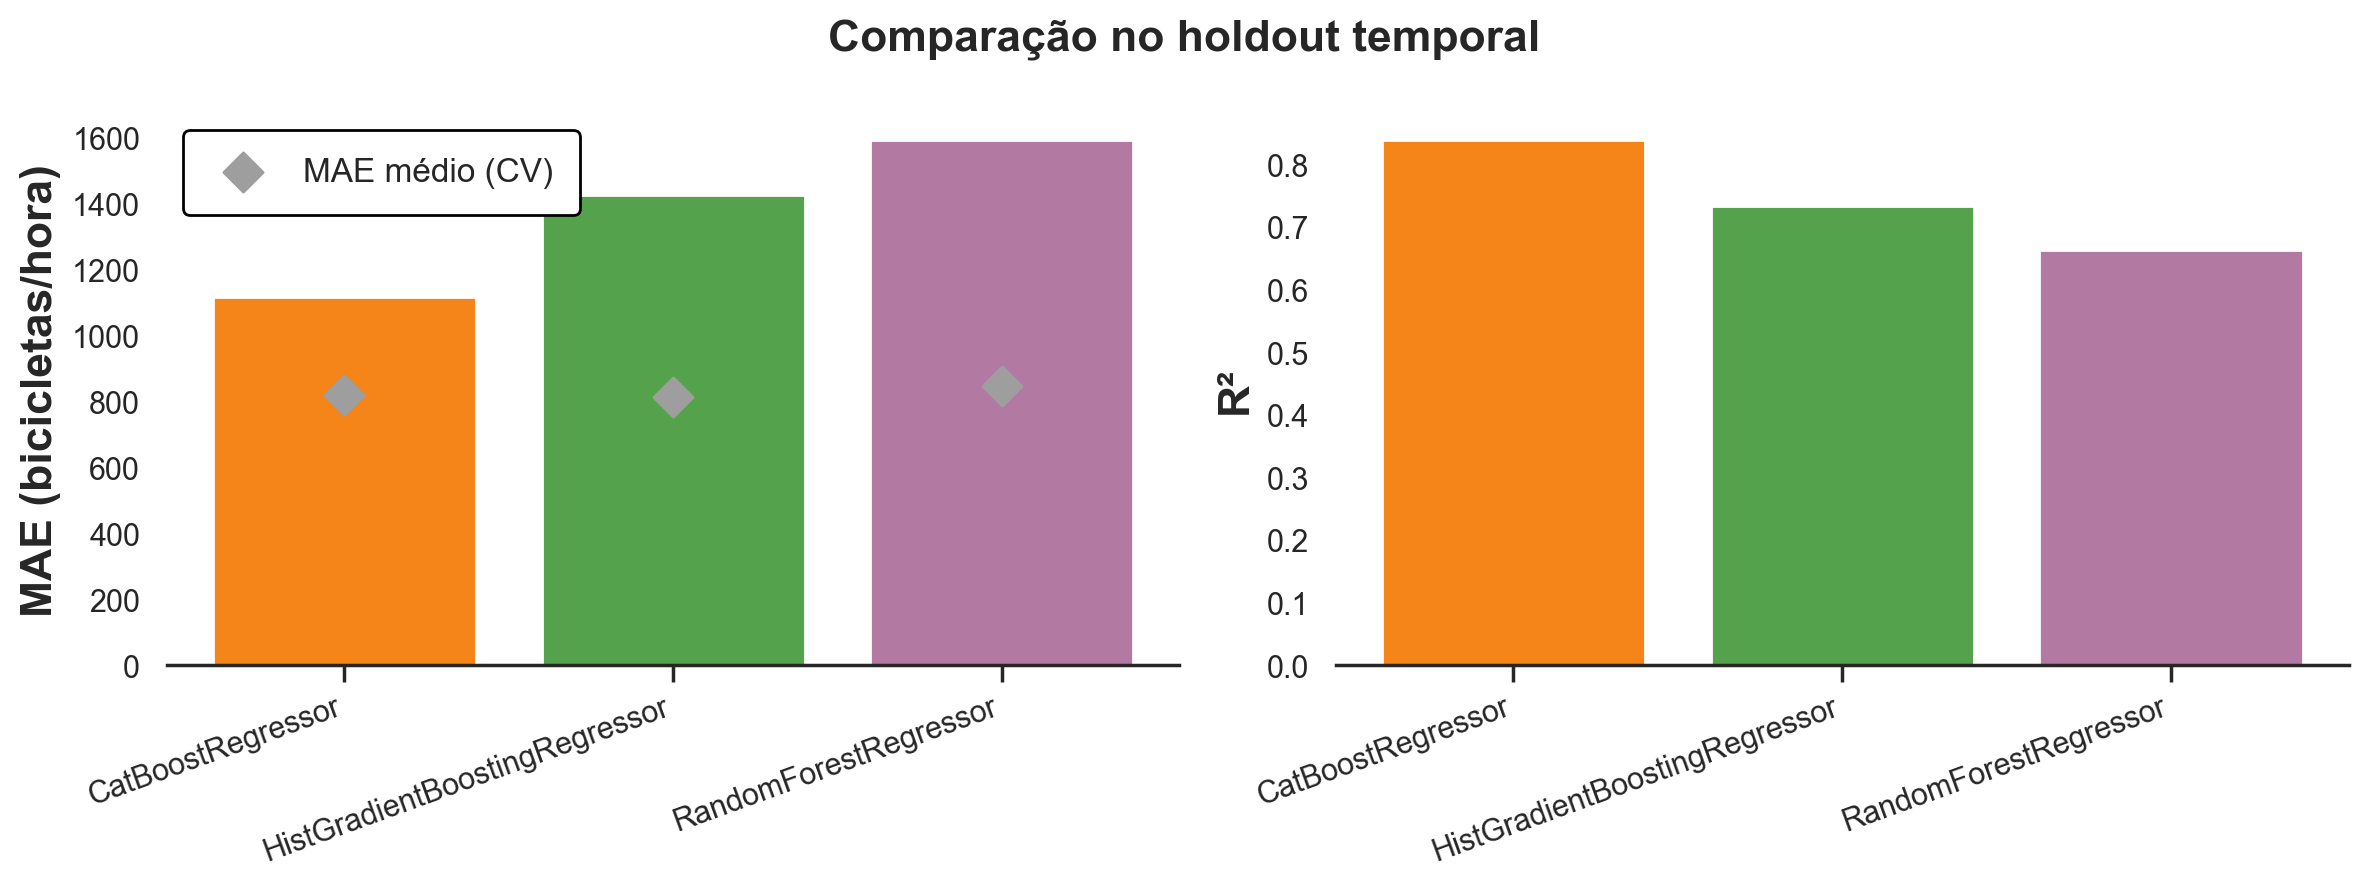

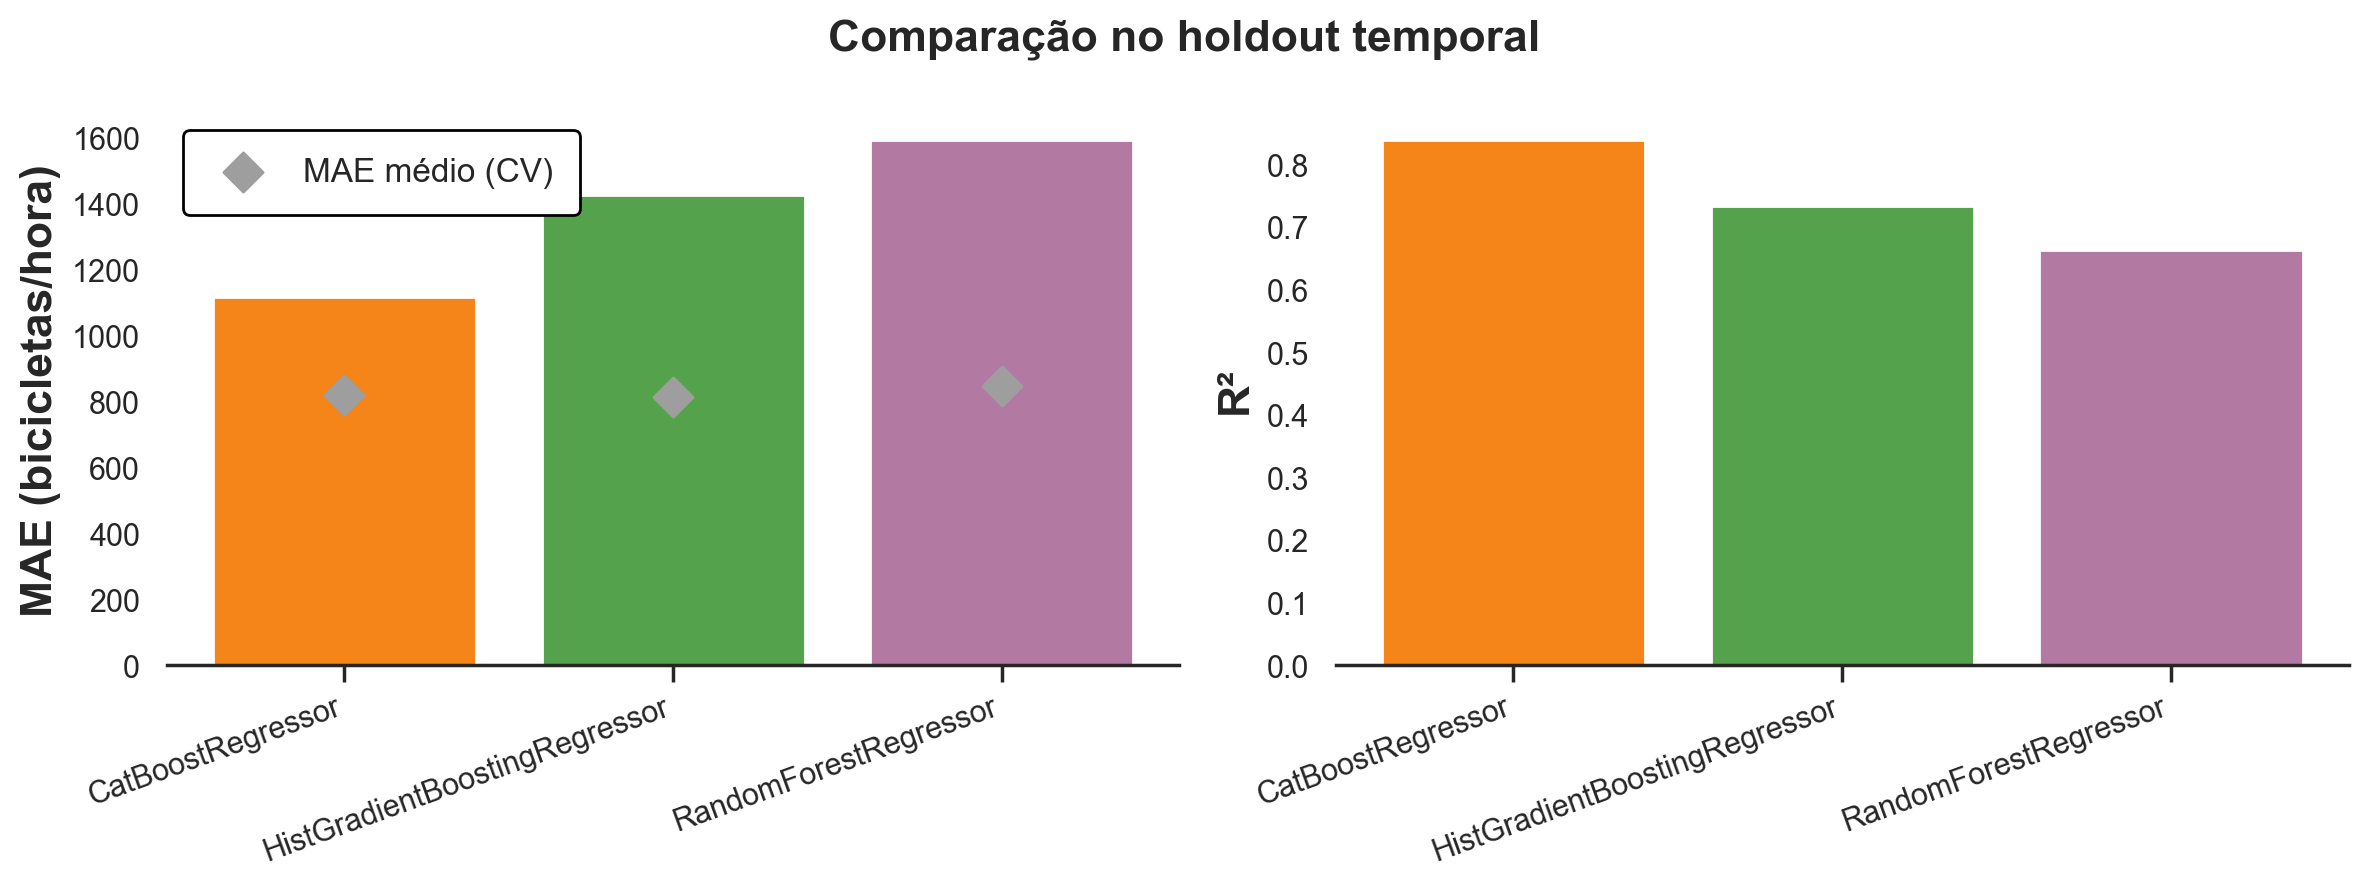

In [8]:
reports.plot_comparison(results, lang=lang)

## 6. Confirmação do champion

A regra pré-registrada é aplicada aos números observados no holdout. A decisão resultante e as
condições que a produziram são apresentadas de forma tabular, e uma narrativa dependente dos valores
reais é produzida dinamicamente pela camada de relatórios, uma vez que ela não pode ser antecipada
antes da execução.

In [9]:
reports.confirmation_report(results, lang=lang)

,Item,Valor
0,Decisão,Champion confirmado
1,MAE do champion,1118.087
2,R² do champion,0.8393
3,Menor MAE entre os três,1118.087
4,Maior R² entre os três,0.8393
5,"Limiar de MAE (1,05 × menor)",1173.991
6,"Limiar de R² (maior − 0,02)",0.8193
7,Condição de MAE satisfeita,True
8,Condição de R² satisfeita,True
9,Melhor desempenho no holdout,CatBoostRegressor


In [10]:
reports.confirmation_message(results, lang=lang)

'O champion pré-registrado CatBoostRegressor foi confirmado no holdout temporal. Ambas as condições pré-registradas foram satisfeitas, e a diferença de MAE para o melhor candidato (CatBoostRegressor) é de 0.00 bicicletas/hora, uma distância pequena que não caracteriza superioridade substantiva de nenhum concorrente.'

## 7. Resíduos temporais

Os resíduos são analisados na convenção de y menos ŷ, de modo que um resíduo positivo corresponde a uma subestimação. São apresentados os resíduos ao longo do tempo, a média móvel do resíduo e do erro absoluto, a comparação entre observado e previsto em uma janela recente, além da distribuição, do QQ plot, do gráfico de resíduo contra valor previsto, das funções de autocorrelação e autocorrelação parcial e da calibração por decis. Com milhares de observações, um teste de normalidade rejeitaria desvios pequenos; por isso, a assimetria, as caudas e a autocorrelação são tratadas como diagnósticos, e não como critério binário de validade.

O relatório formal acrescenta Breusch-Pagan na versão robusta de Koenker, White, Goldfeld-Quandt bilateral e Engle ARCH nos lags horários 24 e 168. A hipótese nula é sempre a ausência de evidência contra variância constante, exceto no ARCH, em que H0 indica ausência de heterocedasticidade condicional até a defasagem especificada. A interpretação é feita pelo p-valor ajustado por Holm dentro de cada candidato: p menor que alfa indica evidência diagnóstica contra H0, enquanto p maior ou igual a alfa indica apenas evidência insuficiente para rejeitá-la, nunca uma prova de homocedasticidade. Breusch-Pagan, White e Goldfeld-Quandt são sensíveis à dependência temporal dos resíduos; por isso, a autocorrelação é analisada em uma etapa própria antes que qualquer hipótese de volatilidade condicional seja priorizada.


In [11]:
reports.residual_diagnostics_report(results, lang=lang)

,Papel,Estimator,Média do resíduo,Desvio do resíduo,Assimetria,Curtose,Durbin–Watson,Autocorr. lag 1,Autocorr. lag 24,Autocorr. lag 168
0,Champion,CatBoostRegressor,-1000.094704,1256.294481,-1.309081,5.139752,0.407160,0.667260,0.515381,0.452973
1,Challenger,HistGradientBoostingRegressor,-1278.903696,1627.404517,-1.337498,3.429531,0.338348,0.726268,0.602371,0.569722
2,Challenger,RandomForestRegressor,-1407.498130,1847.191959,-1.424587,4.221519,0.374569,0.703924,0.622515,0.597612


In [12]:
reports.heteroscedasticity_report(results, lang=lang)

,Papel,Estimator,Teste,Hipotese nula,Estatistica,p-valor bruto,p-valor ajustado (Holm),Alfa,Evidencia de heterocedasticidade,Observacoes,Especificacao diagnostica,Limitacoes,Status,Motivo
0,Champion,CatBoostRegressor,Breusch-Pagan (Koenker),Residual variance is constant against fitted-v...,2365.813082,abaixo da precisão numérica,abaixo da precisão numérica,0.05,Sim,8784,Koenker robust LM test; auxiliary variables: i...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Aplicavel,
1,Champion,CatBoostRegressor,White,Residual variance is constant against fitted-v...,2365.813082,abaixo da precisão numérica,abaixo da precisão numérica,0.05,Sim,8784,White LM test with low-dimensional exog: inter...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Aplicavel,
2,Champion,CatBoostRegressor,Goldfeld-Quandt,The two ordered residual subsamples have equal...,5.002159,abaixo da precisão numérica,abaixo da precisão numérica,0.05,Sim,8784,Two-sided test sorted by prediction; central 2...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Aplicavel,
3,Champion,CatBoostRegressor,Engle ARCH (lag 24),There is no ARCH effect up to the specified lag.,2577.201592,abaixo da precisão numérica,abaixo da precisão numérica,0.05,Sim,8784,"LM test on squared residual lags 1..24, using ...",Diagnostic only; preserves the residual time o...,Aplicavel,
4,Champion,CatBoostRegressor,Engle ARCH (lag 168),There is no ARCH effect up to the specified lag.,3050.499624,abaixo da precisão numérica,abaixo da precisão numérica,0.05,Sim,8784,"LM test on squared residual lags 1..168, using...",Diagnostic only; preserves the residual time o...,Aplicavel,
5,Challenger,HistGradientBoostingRegressor,Breusch-Pagan (Koenker),Residual variance is constant against fitted-v...,4108.931822,abaixo da precisão numérica,abaixo da precisão numérica,0.05,Sim,8784,Koenker robust LM test; auxiliary variables: i...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Aplicavel,
6,Challenger,HistGradientBoostingRegressor,White,Residual variance is constant against fitted-v...,4108.931822,abaixo da precisão numérica,abaixo da precisão numérica,0.05,Sim,8784,White LM test with low-dimensional exog: inter...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Aplicavel,
7,Challenger,HistGradientBoostingRegressor,Goldfeld-Quandt,The two ordered residual subsamples have equal...,6.357627,abaixo da precisão numérica,abaixo da precisão numérica,0.05,Sim,8784,Two-sided test sorted by prediction; central 2...,"Diagnostic only; BP, White and Goldfeld-Quandt...",Aplicavel,
8,Challenger,HistGradientBoostingRegressor,Engle ARCH (lag 24),There is no ARCH effect up to the specified lag.,3899.749613,abaixo da precisão numérica,abaixo da precisão numérica,0.05,Sim,8784,"LM test on squared residual lags 1..24, using ...",Diagnostic only; preserves the residual time o...,Aplicavel,
9,Challenger,HistGradientBoostingRegressor,Engle ARCH (lag 168),There is no ARCH effect up to the specified lag.,4604.883686,abaixo da precisão numérica,abaixo da precisão numérica,0.05,Sim,8784,"LM test on squared residual lags 1..168, using...",Diagnostic only; preserves the residual time o...,Aplicavel,


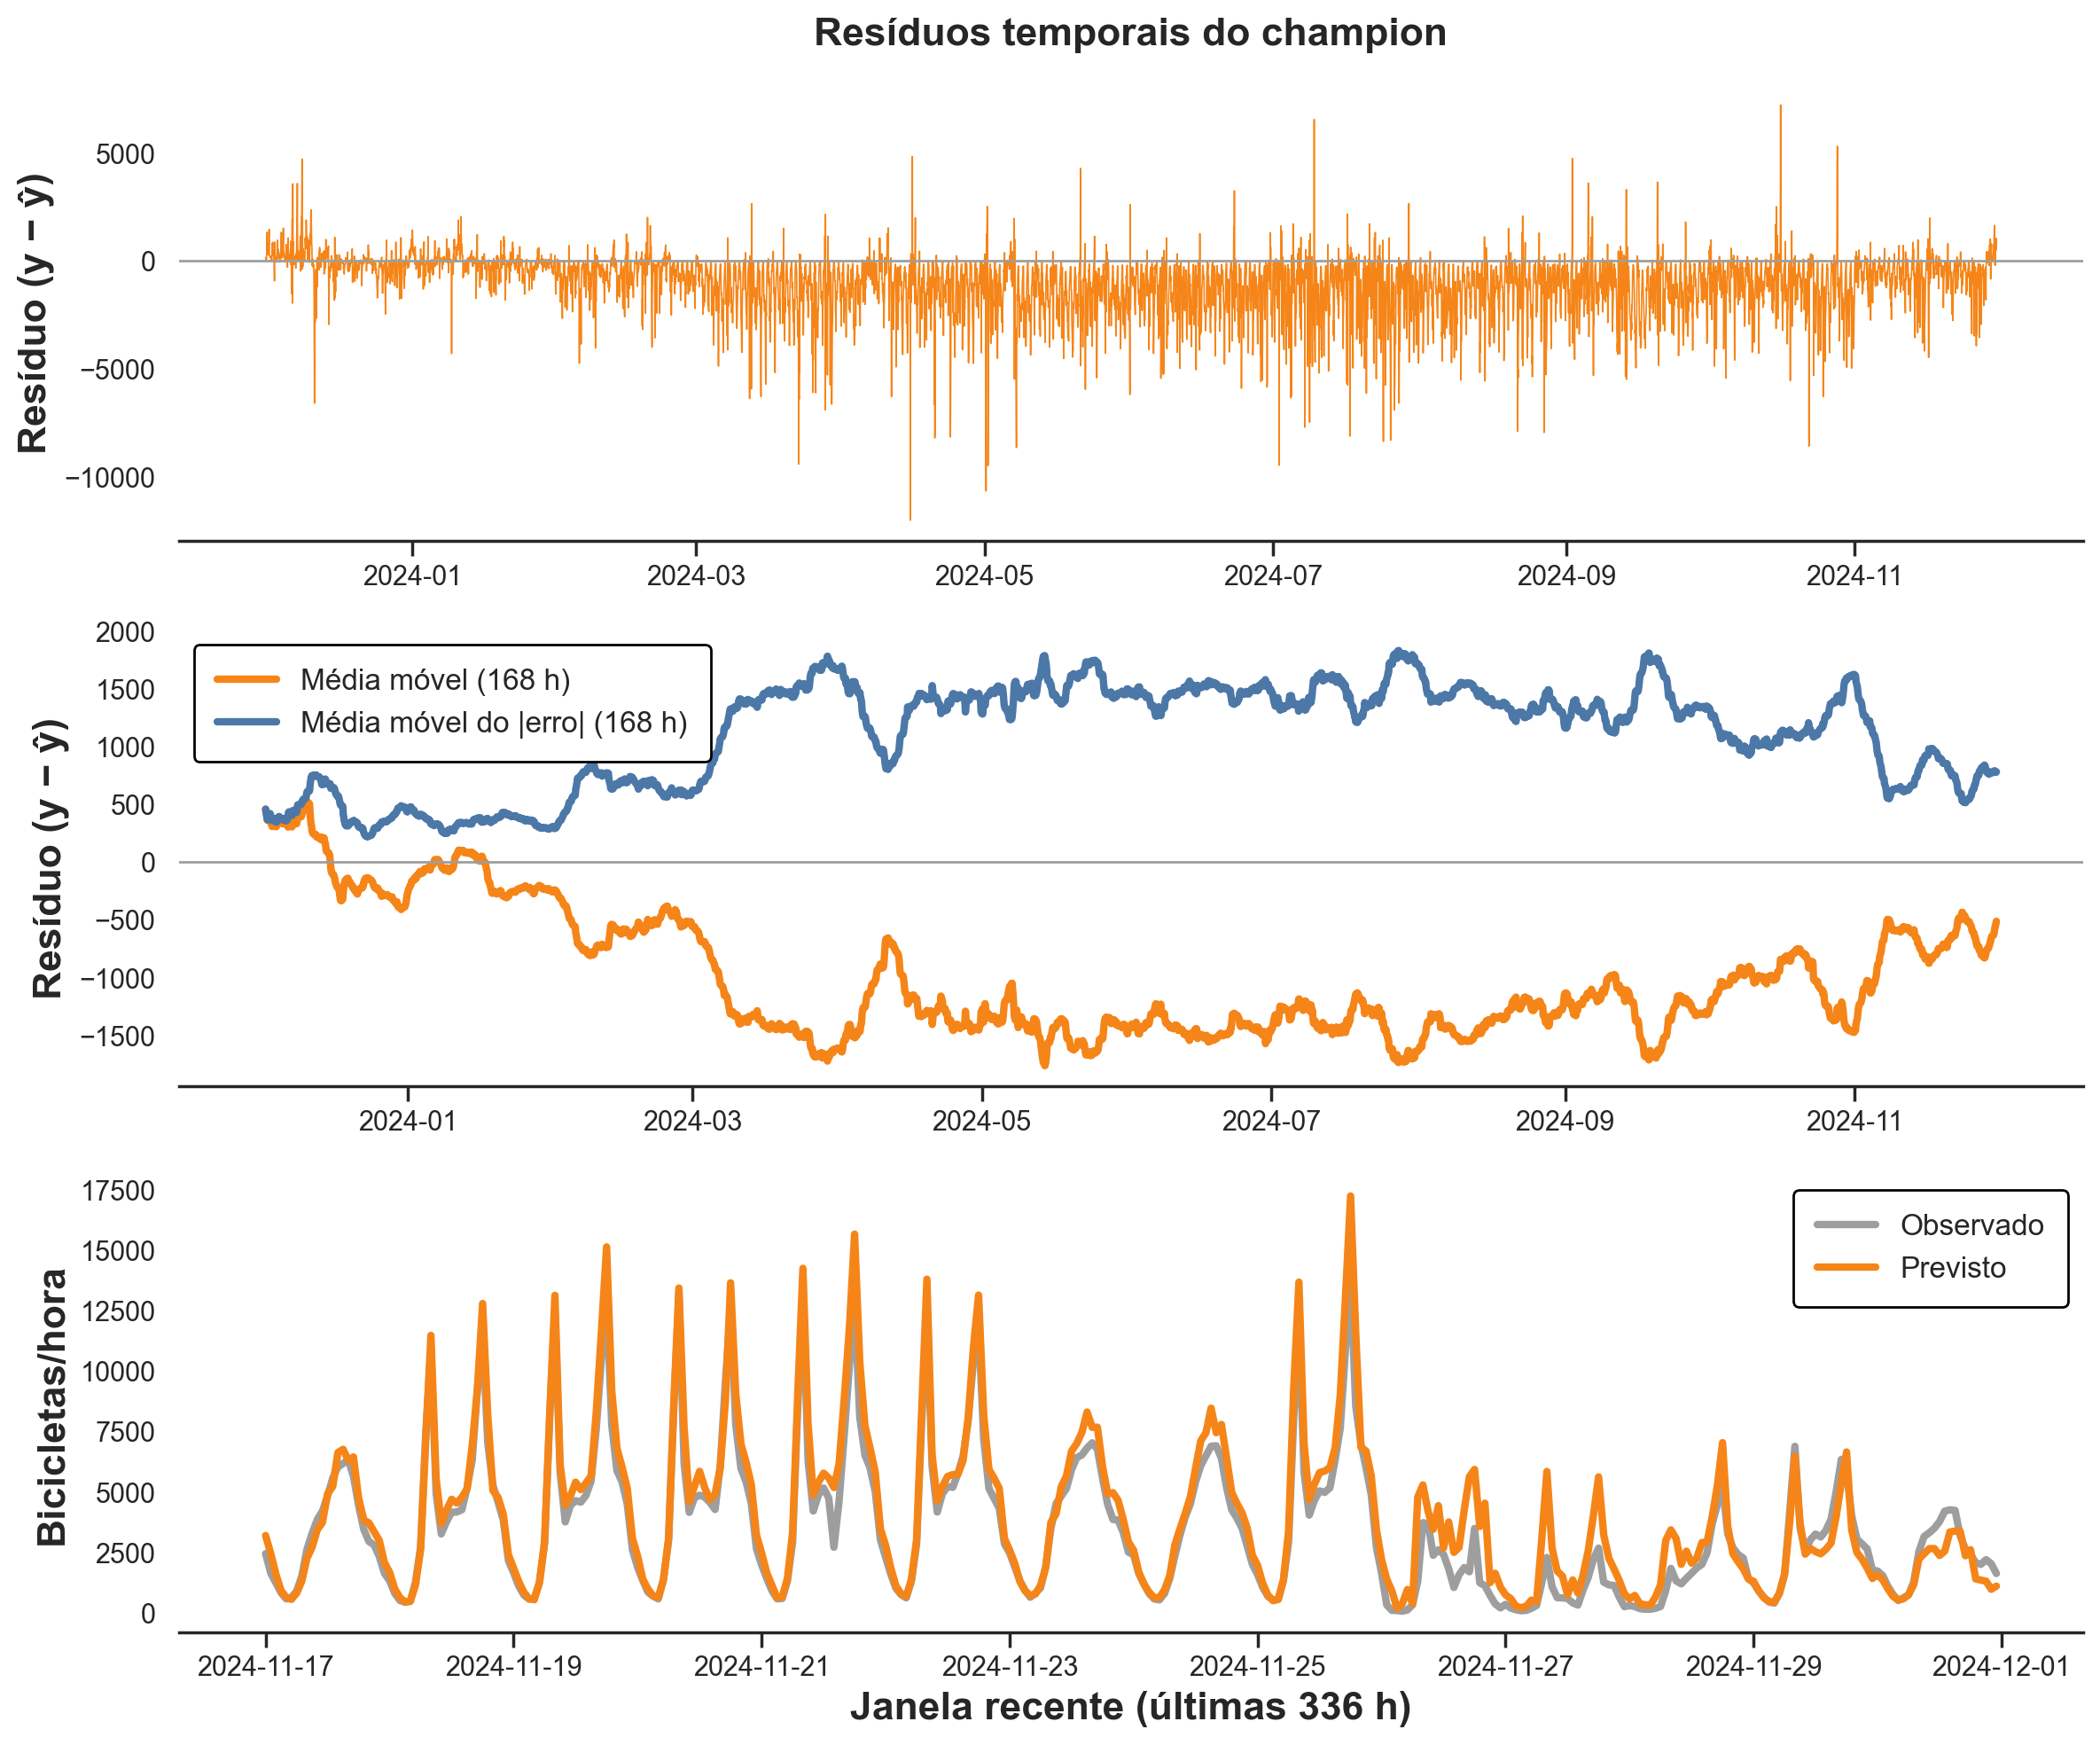

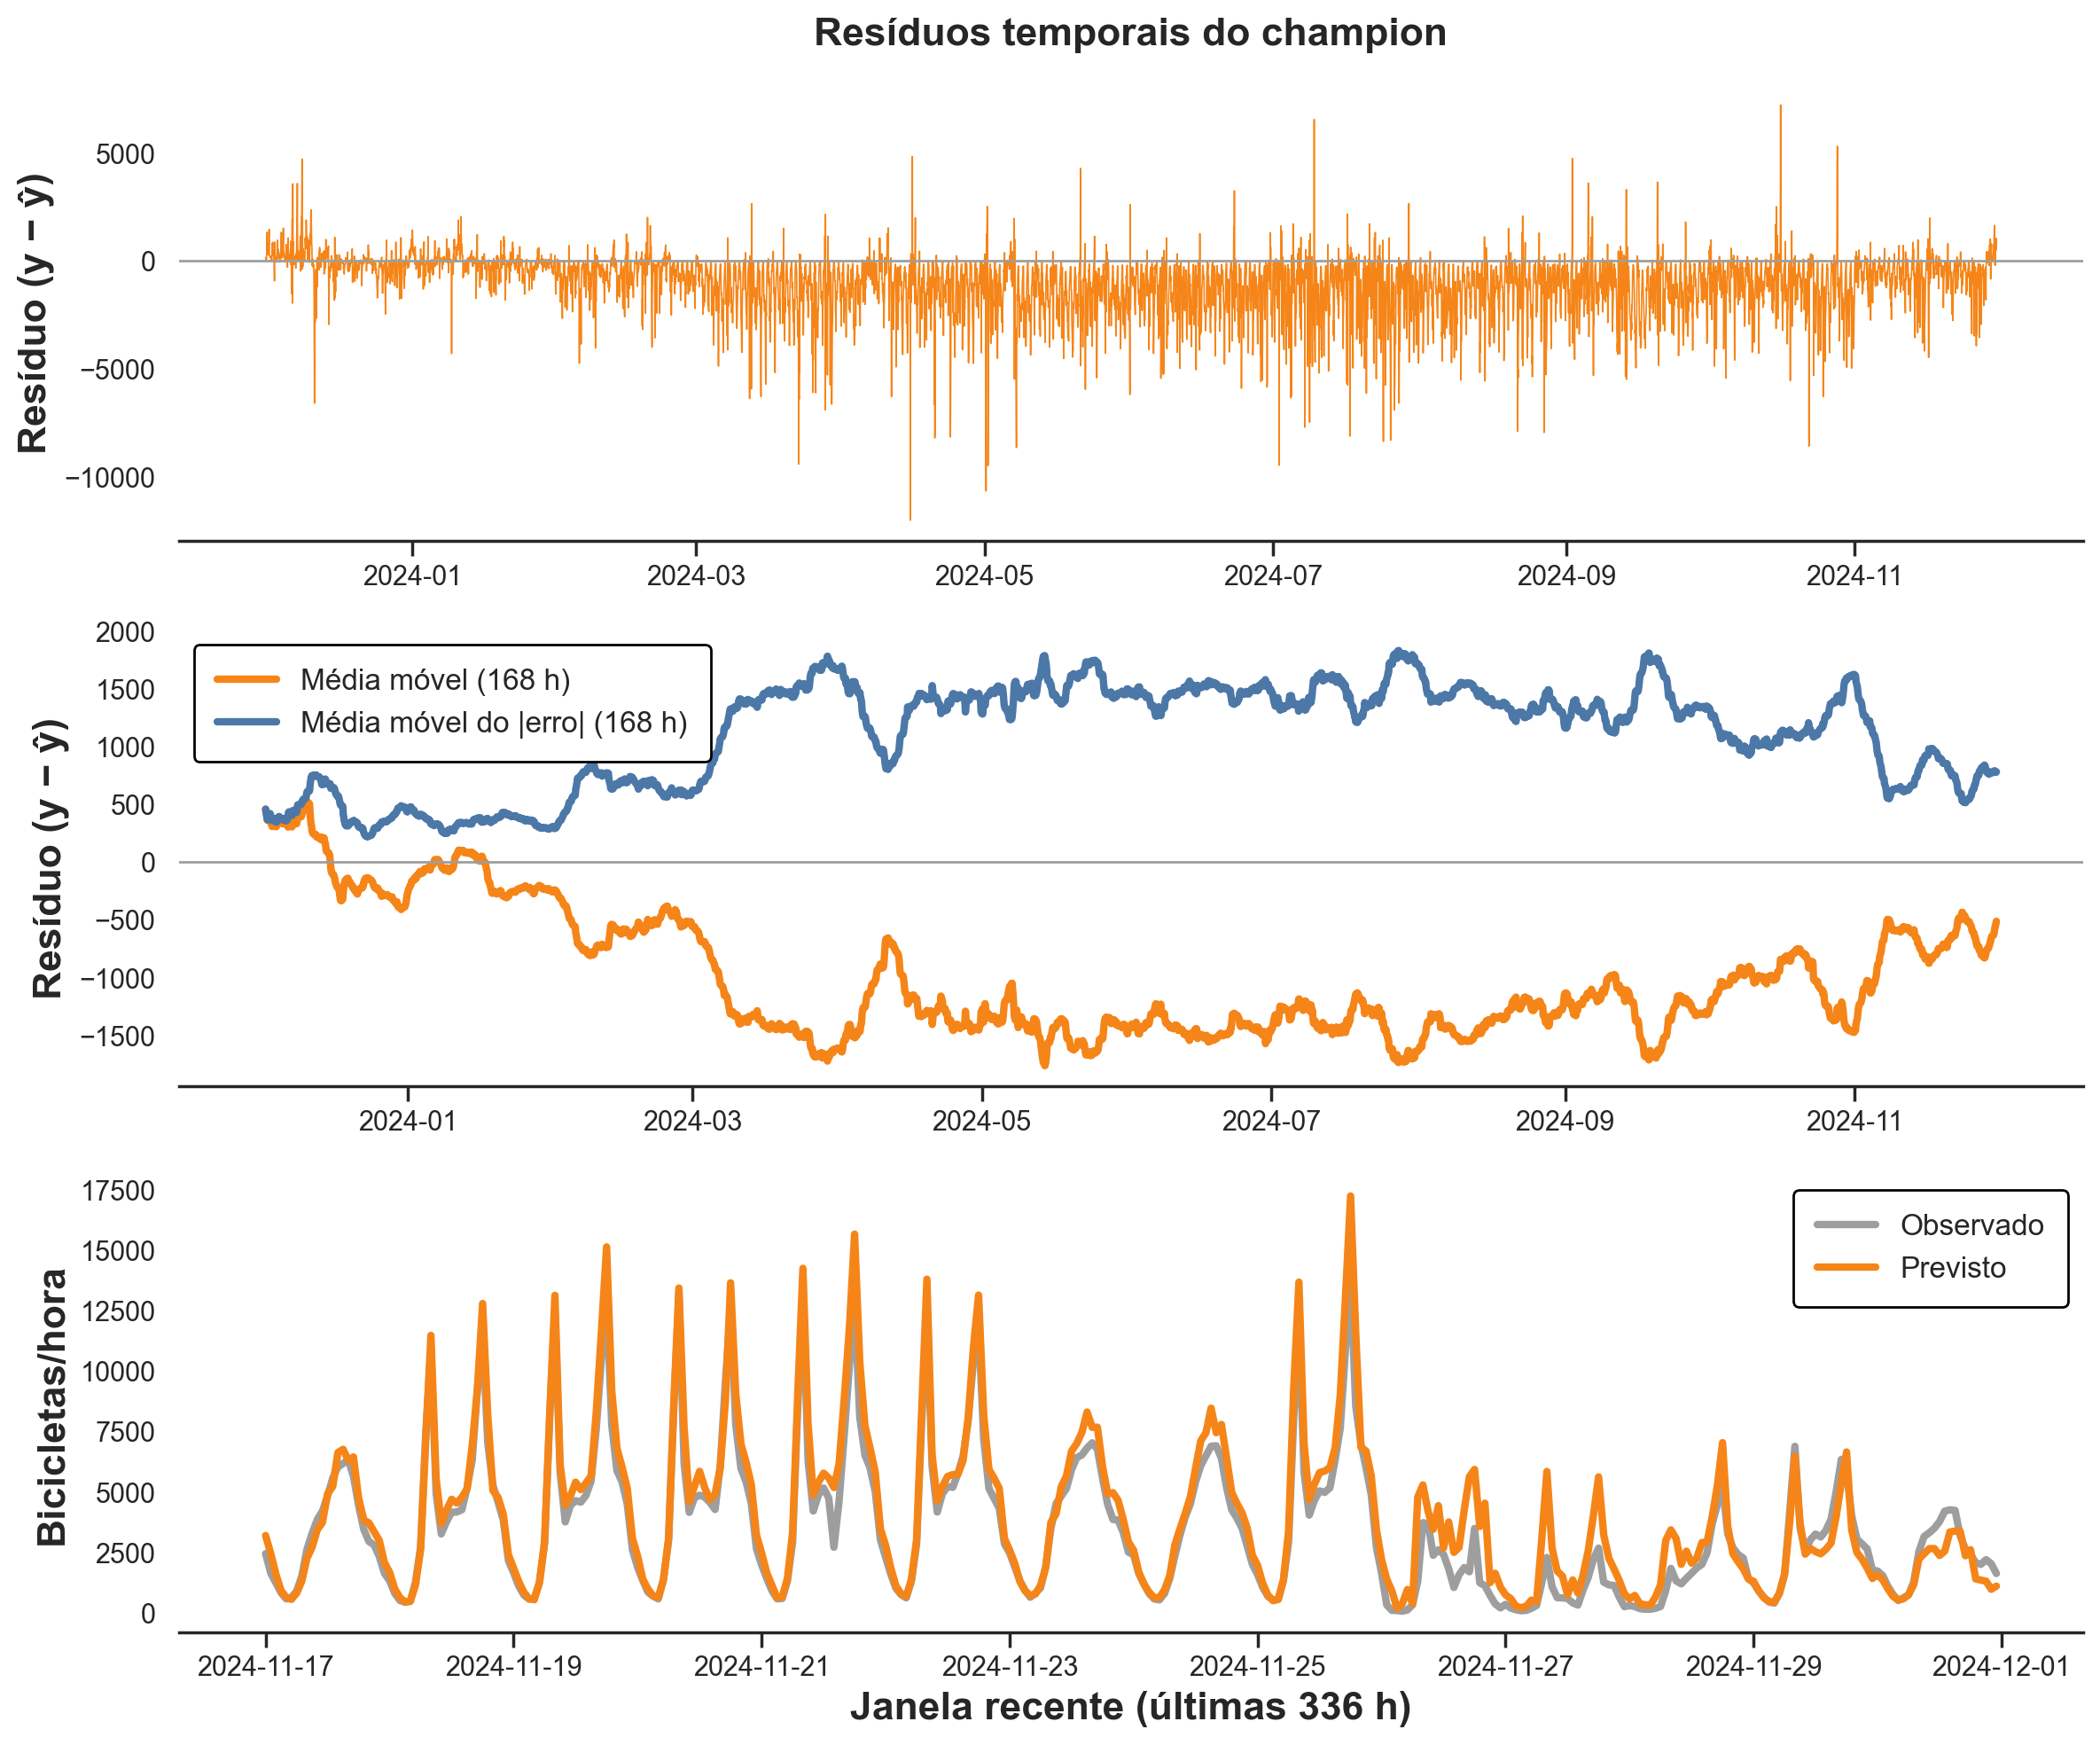

In [13]:
reports.plot_temporal_residuals(results, lang=lang)

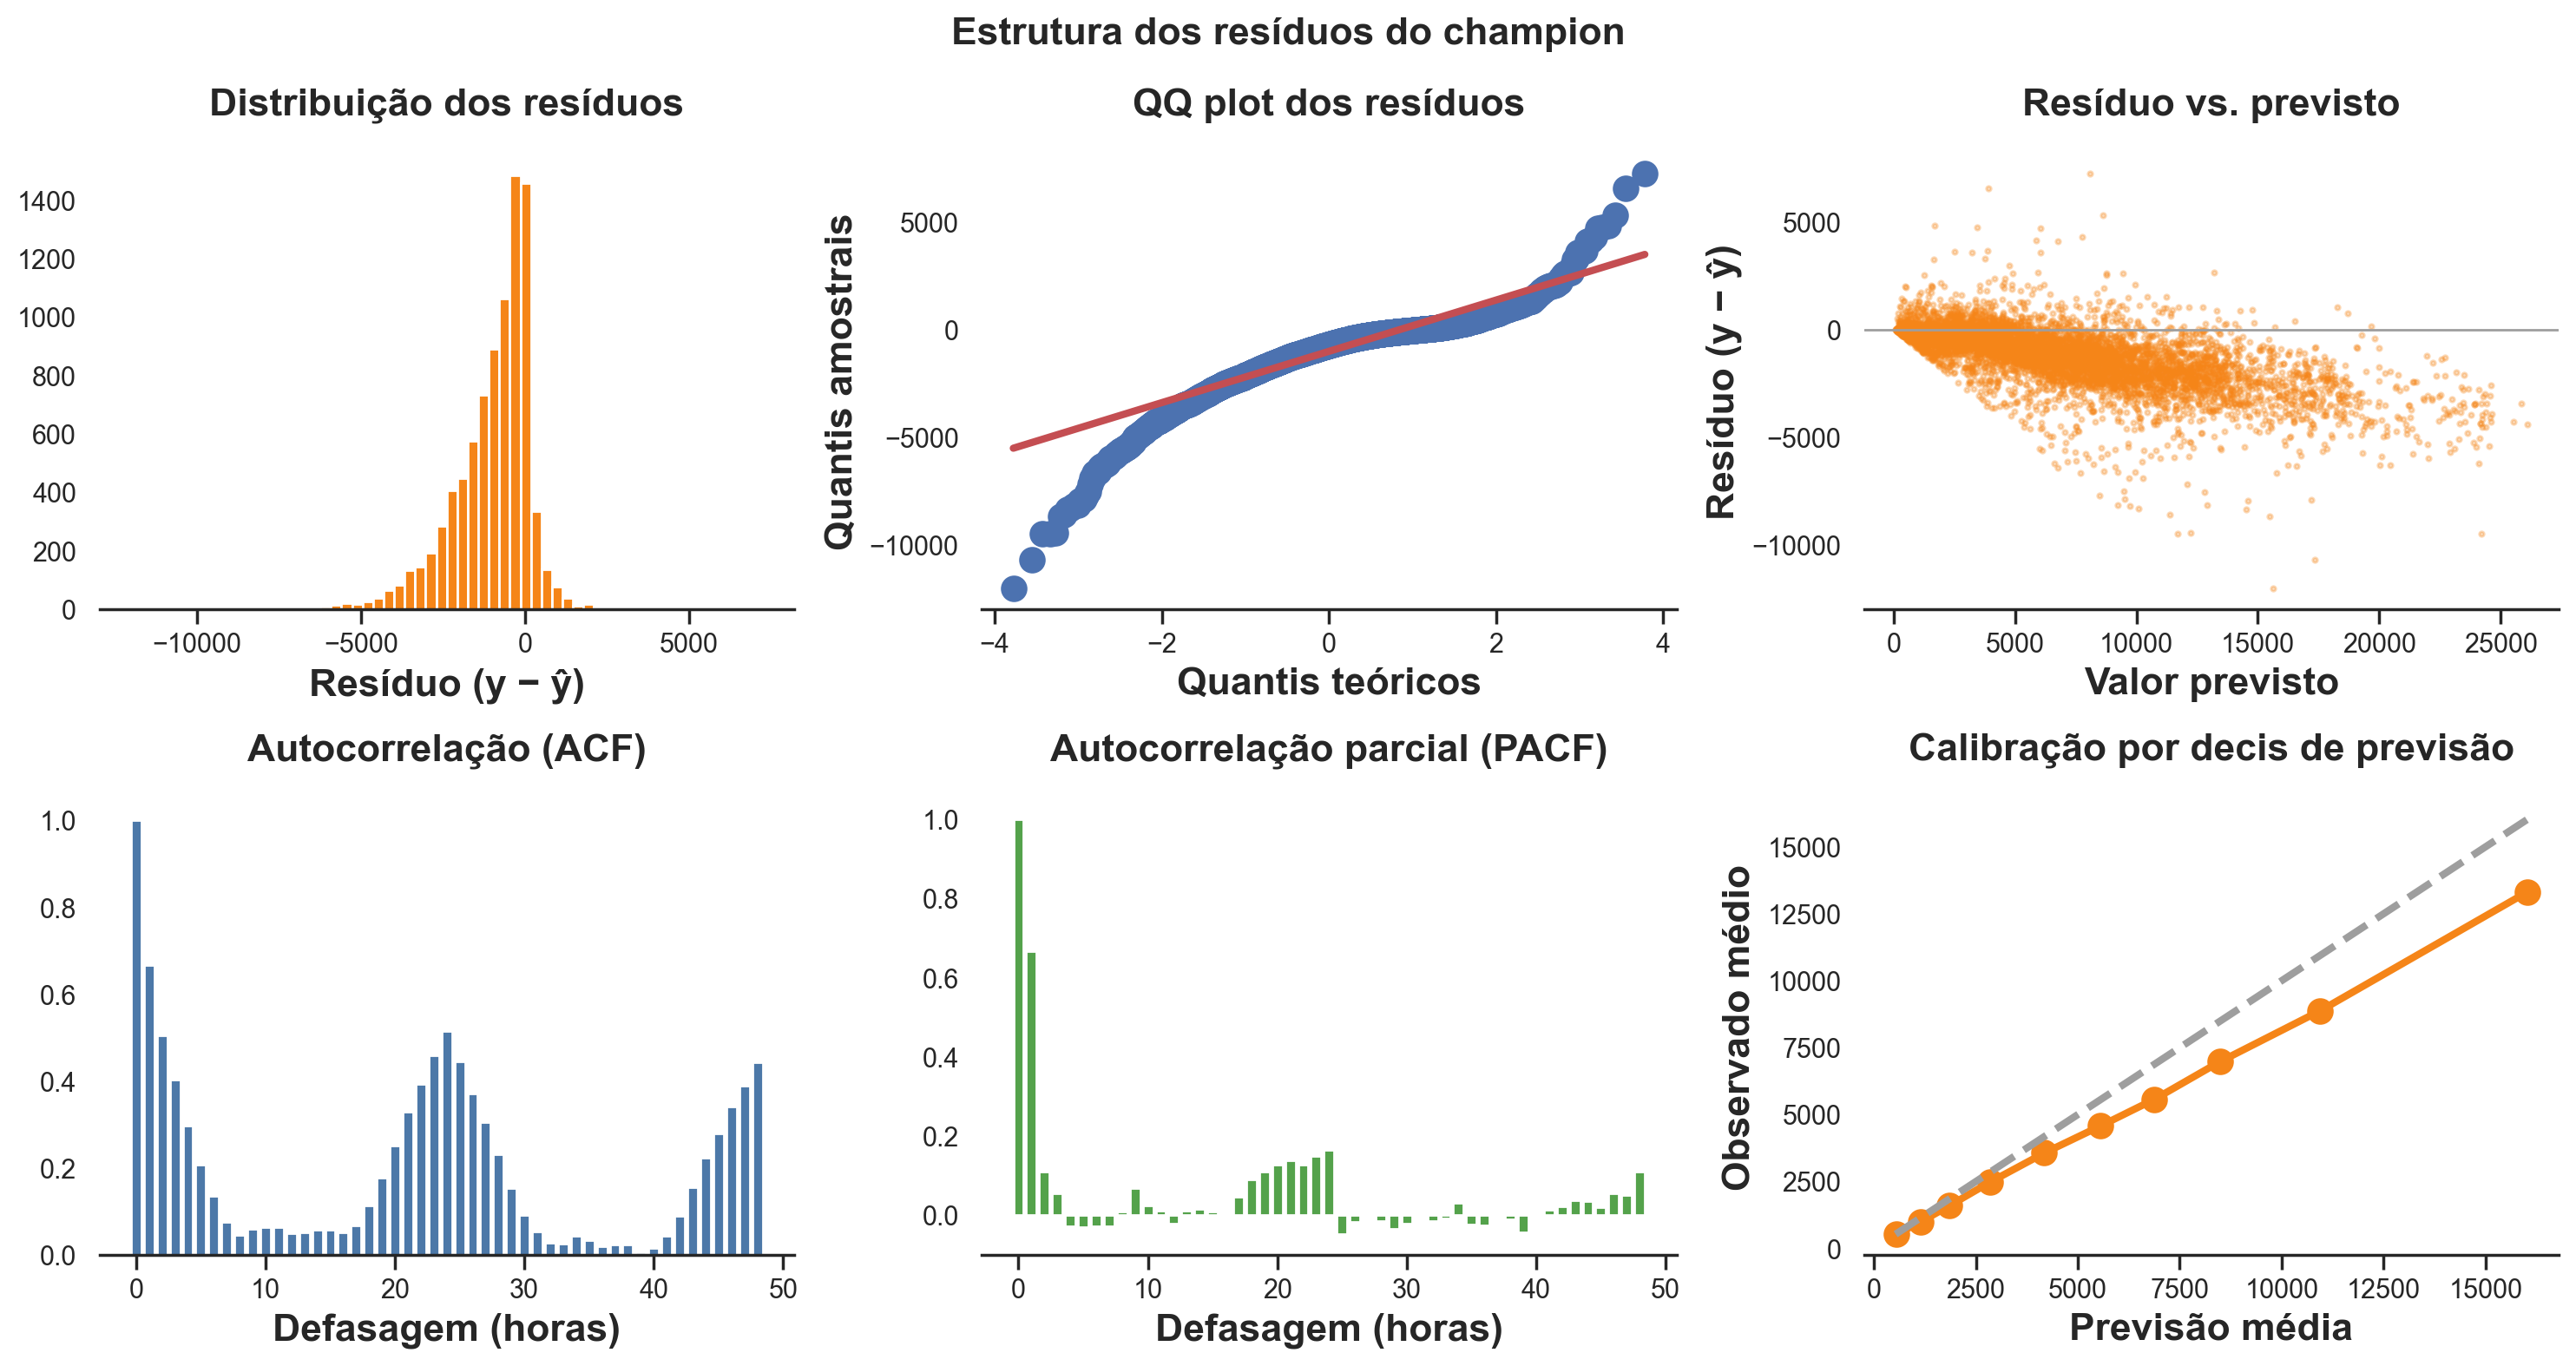

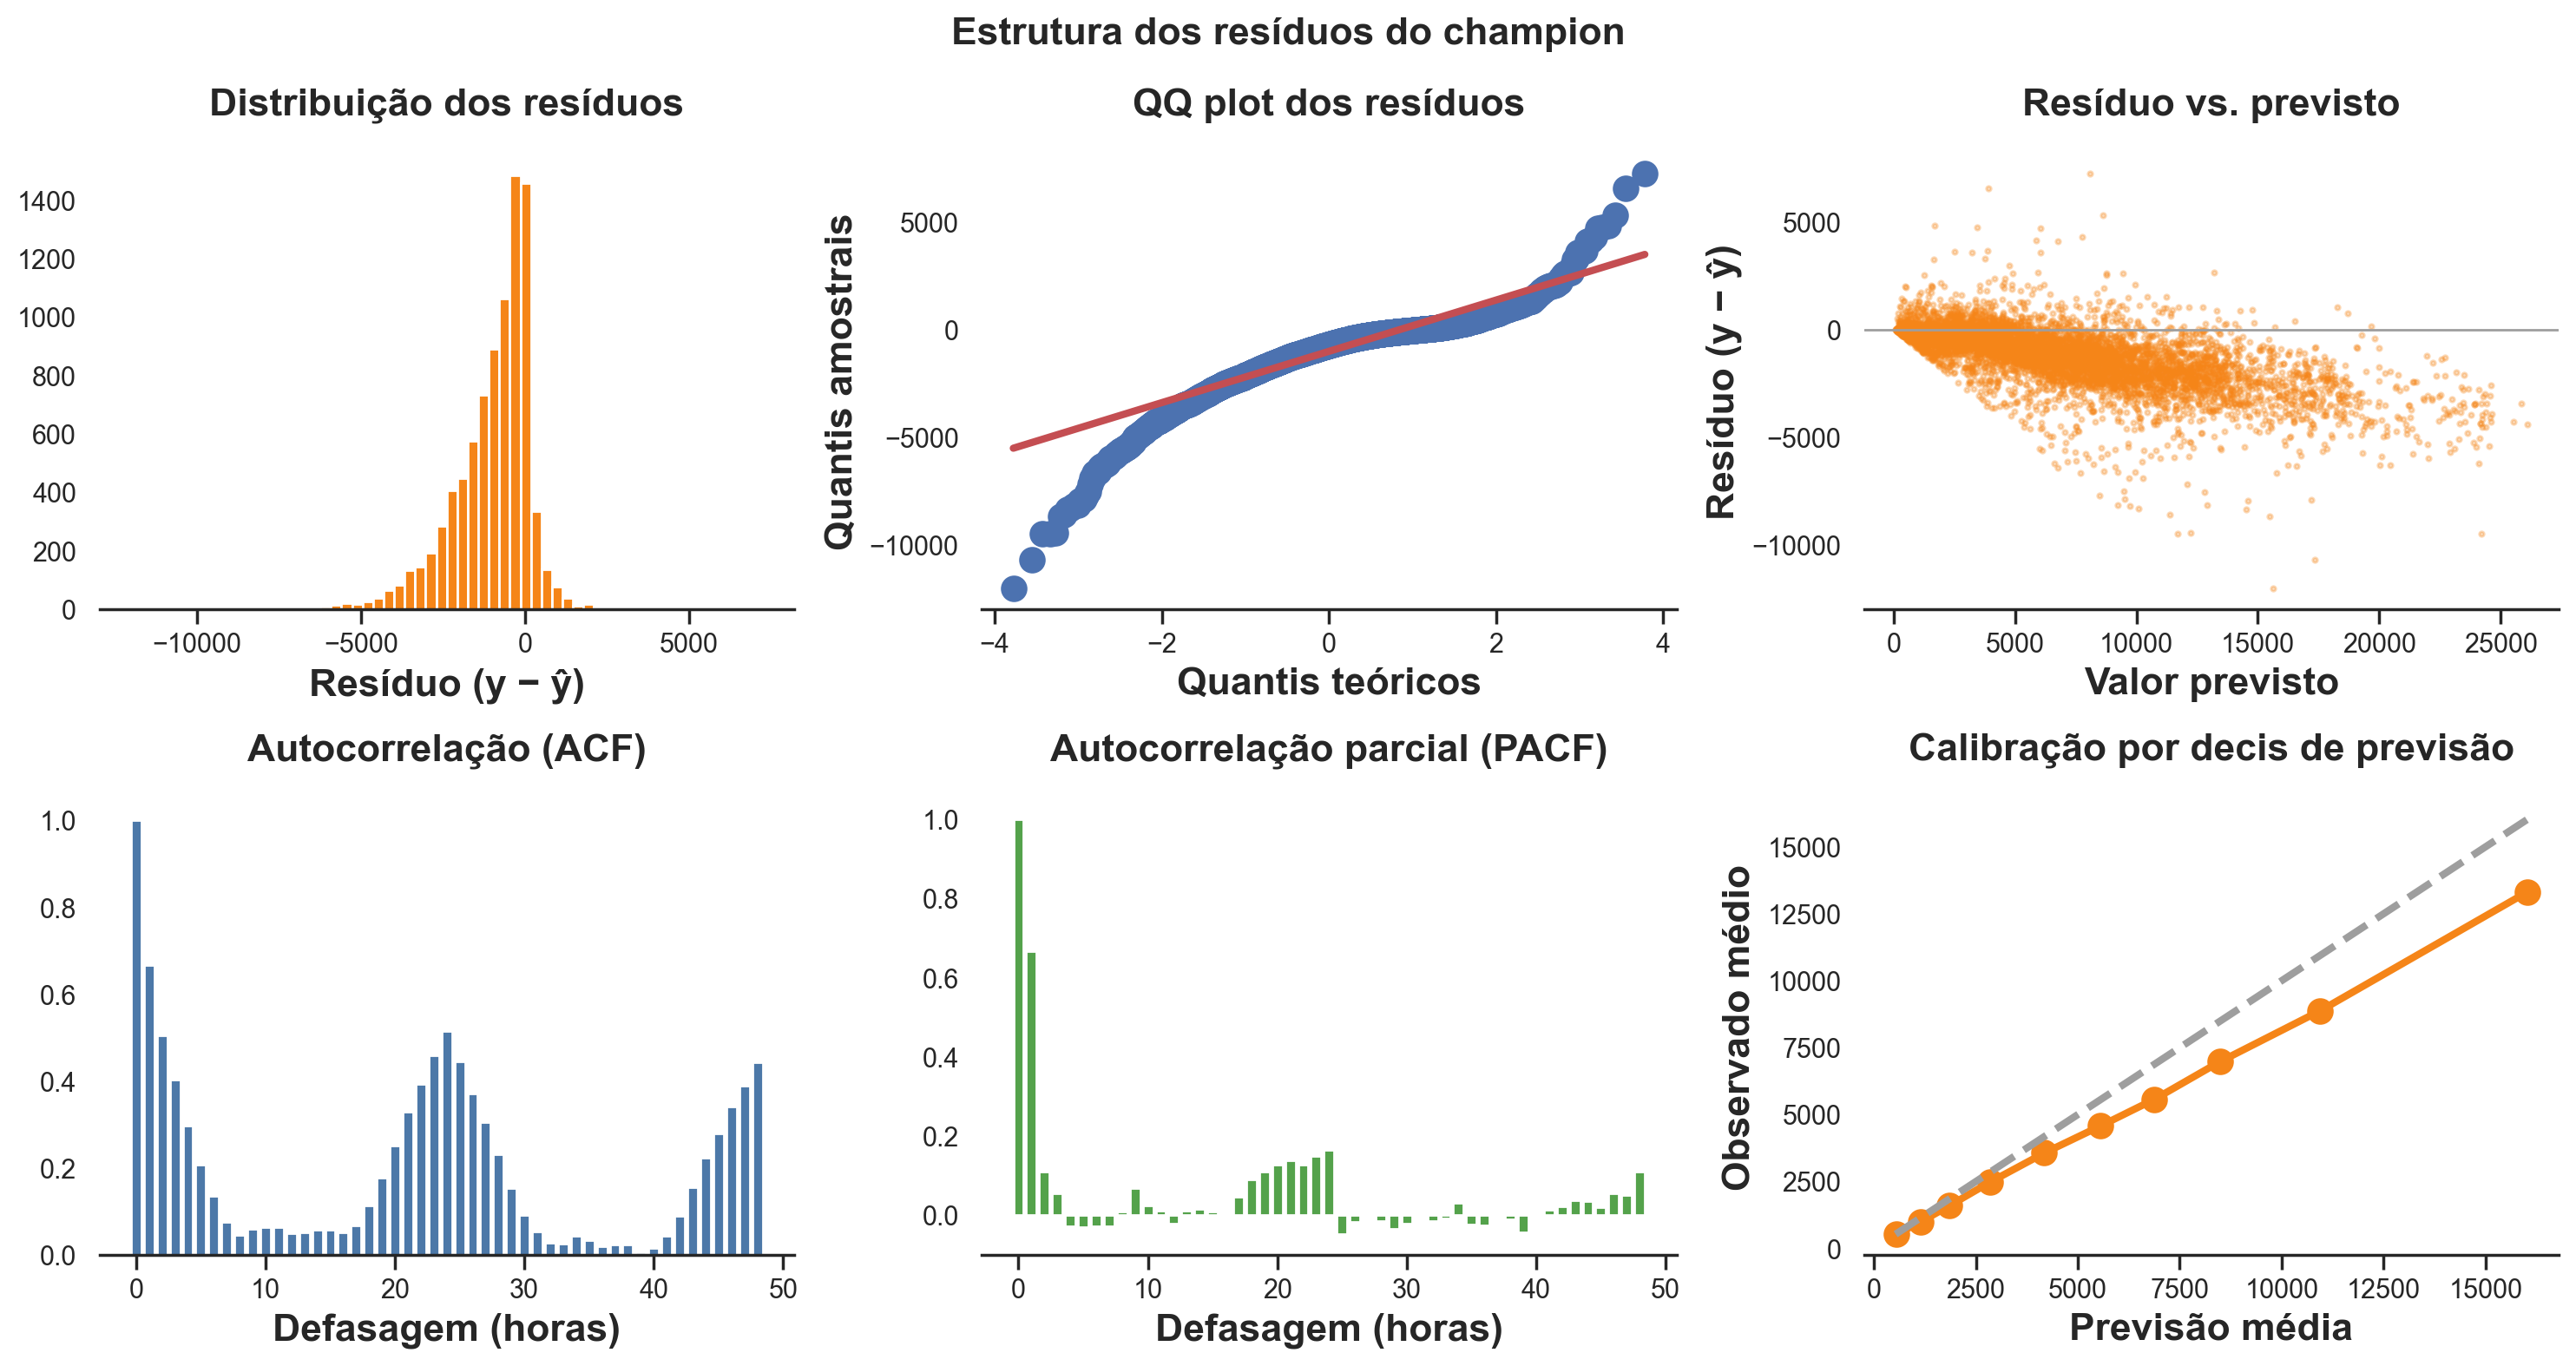

In [14]:
reports.plot_residual_structure(results, lang=lang)

### 7.1 Triagem da média residual e da escala do erro

A triagem pós-holdout é adicionada como leitura diagnóstica do Champion confirmado. O bias é medido como ŷ menos y, enquanto o resíduo linha a linha é mantido como y menos ŷ. Com essa separação, pode ser verificado se o erro está predominantemente deslocado na média, se a escala do erro cresce com o nível previsto e se os picos de erro ficam concentrados em calendários específicos.

Os perfis por mês, hora, estação e decil da previsão são calculados apenas a partir das previsões e resíduos persistidos em `FinalValidationResults`. Nenhum pipeline é reajustado, nenhuma predição nova é solicitada e nenhuma variável meteorológica adicional é reaberta a partir do dataset bruto.


In [15]:
reports.residual_triage_report(results, lang=lang)


,Estimator,Lag ARCH,MAE,Bias médio (ŷ-y),|bias| / MAE,Durbin-Watson,Autocorr. lag 1,Autocorr. lag 24,Autocorr. lag 168,Razão desvio residual por nível previsto,Razão MAE por nível previsto,ARCH original,ARCH padronizado,Redução ARCH após padronização,ARCH/n original,ARCH/n padronizado,ARCH persiste após padronização,Uso diagnóstico
0,CatBoostRegressor,24,1118.087076,1000.094704,0.894469,0.40716,0.66726,0.515381,0.452973,5.711271,17.626275,2577.201592,1336.574975,0.481385,0.294201,0.152577,Sim,Sim
1,CatBoostRegressor,168,1118.087076,1000.094704,0.894469,0.40716,0.66726,0.515381,0.452973,5.711271,17.626275,3050.499624,1570.027051,0.485321,0.354051,0.182222,Sim,Sim


In [16]:
reports.residual_profile_report(results, 'month', lang=lang)


,Dimensão,Segmento,Observações,Demanda média observada,Previsão média,Bias médio (ŷ-y),Resíduo médio (y-ŷ),MAE,RMSE,Desvio residual,Proporção de superestimações,Proporção de subestimações
0,month,Sim,744,2601.338710,2734.708598,133.369888,-133.369888,340.955941,509.741176,492.315256,0.610215,0.389785
1,month,2,696,2844.652299,3462.332269,617.679970,-617.679970,698.750568,972.159839,751.250353,0.841954,0.158046
2,month,3,744,4131.861559,5533.581785,1401.720226,-1401.720226,1437.066244,1930.167782,1327.816942,0.966398,0.033602
3,month,4,720,6257.427778,7456.854813,1199.427035,-1199.427035,1265.286892,1754.739712,1281.705062,0.933333,0.066667
4,month,5,744,6304.350806,7791.453639,1487.102832,-1487.102832,1568.377730,2033.148263,1387.373103,0.935484,0.064516
5,month,6,720,6607.769444,8020.898554,1413.129110,-1413.129110,1444.458126,1846.586480,1189.501116,0.977778,0.022222
6,month,7,744,4878.625000,6295.989193,1417.364193,-1417.364193,1523.976263,2143.472123,1609.046727,0.909946,0.090054
7,month,8,744,5186.048387,6509.687947,1323.639560,-1323.639560,1355.192076,1797.943146,1217.608548,0.965054,0.034946
8,month,9,720,5758.645833,7052.397801,1293.751967,-1293.751967,1393.156942,1785.124232,1230.844632,0.919444,0.080556
9,month,10,744,6127.263441,7209.793199,1082.529758,-1082.529758,1209.456865,1640.421731,1233.352077,0.905914,0.094086


In [17]:
reports.residual_profile_report(results, 'hour', lang=lang)


,Dimensão,Segmento,Observações,Demanda média observada,Previsão média,Bias médio (ŷ-y),Resíduo médio (y-ŷ),MAE,RMSE,Desvio residual,Proporção de superestimações,Proporção de subestimações
0,hour,Não,366,2401.795082,2964.946224,563.151142,-563.151142,603.468610,736.020732,474.555179,0.879781,0.120219
1,hour,Sim,366,1655.409836,2043.618483,388.208647,-388.208647,430.336652,533.022633,365.749467,0.874317,0.125683
2,hour,2,366,1090.710383,1332.041295,241.330912,-241.330912,283.525752,355.023544,260.742908,0.857923,0.142077
3,hour,3,366,776.368852,902.128314,125.759462,-125.759462,164.806876,221.913570,183.089541,0.784153,0.215847
4,hour,4,366,656.147541,757.166977,101.019436,-101.019436,135.046081,181.013213,150.408335,0.770492,0.229508
5,hour,5,366,1185.986339,1326.551727,140.565389,-140.565389,188.307701,247.088288,203.487415,0.743169,0.256831
6,hour,6,366,2548.978142,2859.511041,310.532899,-310.532899,434.708154,608.894850,524.474808,0.792350,0.207650
7,hour,7,366,5956.748634,6784.267481,827.518847,-827.518847,1088.990901,1635.178838,1412.257685,0.800546,0.199454
8,hour,8,366,8499.598361,10107.489875,1607.891515,-1607.891515,1809.184979,2506.179870,1925.031795,0.860656,0.139344
9,hour,9,366,4960.945355,5888.444780,927.499425,-927.499425,1079.410867,1364.752690,1002.517199,0.866120,0.133880


In [18]:
reports.residual_profile_report(results, 'season', lang=lang)


,Dimensão,Segmento,Observações,Demanda média observada,Previsão média,Bias médio (ŷ-y),Resíduo médio (y-ŷ),MAE,RMSE,Desvio residual,Proporção de superestimações,Proporção de subestimações
0,season,Outono,2184,5536.924451,6525.872410,988.947960,-988.947960,1106.457775,1518.149521,1152.114435,0.879579,0.120421
1,season,Primavera,2208,5557.015399,6921.540679,1364.525281,-1364.525281,1425.297500,1911.093953,1338.343032,0.945199,0.054801
2,season,Verão,2208,5546.064764,6930.466826,1384.402061,-1384.402061,1441.173503,1936.311179,1354.090961,0.950634,0.049366
3,season,Inverno,2184,2736.059524,2990.335151,254.275627,-254.275627,492.493188,762.963155,719.509361,0.656593,0.343407


In [19]:
reports.residual_profile_report(results, 'predicted_demand_decile', lang=lang)


,Dimensão,Segmento,Observações,Demanda média observada,Previsão média,Bias médio (ŷ-y),Resíduo médio (y-ŷ),MAE,RMSE,Desvio residual,Proporção de superestimações,Proporção de subestimações
0,predicted_demand_decile,D01,879,533.715586,560.272451,26.556865,-26.556865,155.287580,251.466522,250.202645,0.623436,0.376564
1,predicted_demand_decile,D02,878,988.556948,1141.545895,152.988947,-152.988947,269.618674,385.255806,353.778134,0.801822,0.198178
2,predicted_demand_decile,D03,878,1604.093394,1860.413359,256.319965,-256.319965,400.703656,563.757609,502.404419,0.804100,0.195900
3,predicted_demand_decile,D04,879,2482.529010,2854.031071,371.502061,-371.502061,571.216459,746.838395,648.252950,0.782708,0.217292
4,predicted_demand_decile,D05,878,3567.612756,4180.704400,613.091643,-613.091643,830.601879,1079.934015,889.537712,0.817768,0.182232
5,predicted_demand_decile,D06,878,4573.365604,5555.314706,981.949102,-981.949102,1103.773711,1336.477939,907.130900,0.922551,0.077449
6,predicted_demand_decile,D07,879,5573.597270,6882.108955,1308.511685,-1308.511685,1367.558331,1627.014150,967.490104,0.946530,0.053470
7,predicted_demand_decile,D08,878,6978.162870,8490.256831,1512.093961,-1512.093961,1630.995320,1935.459473,1208.817399,0.944191,0.055809
8,predicted_demand_decile,D09,878,8866.420273,10931.792042,2065.371769,-2065.371769,2113.564801,2439.727924,1299.397879,0.963554,0.036446
9,predicted_demand_decile,D10,879,13307.914676,16019.999325,2712.084650,-2712.084650,2737.141633,3065.134553,1428.975066,0.978385,0.021615


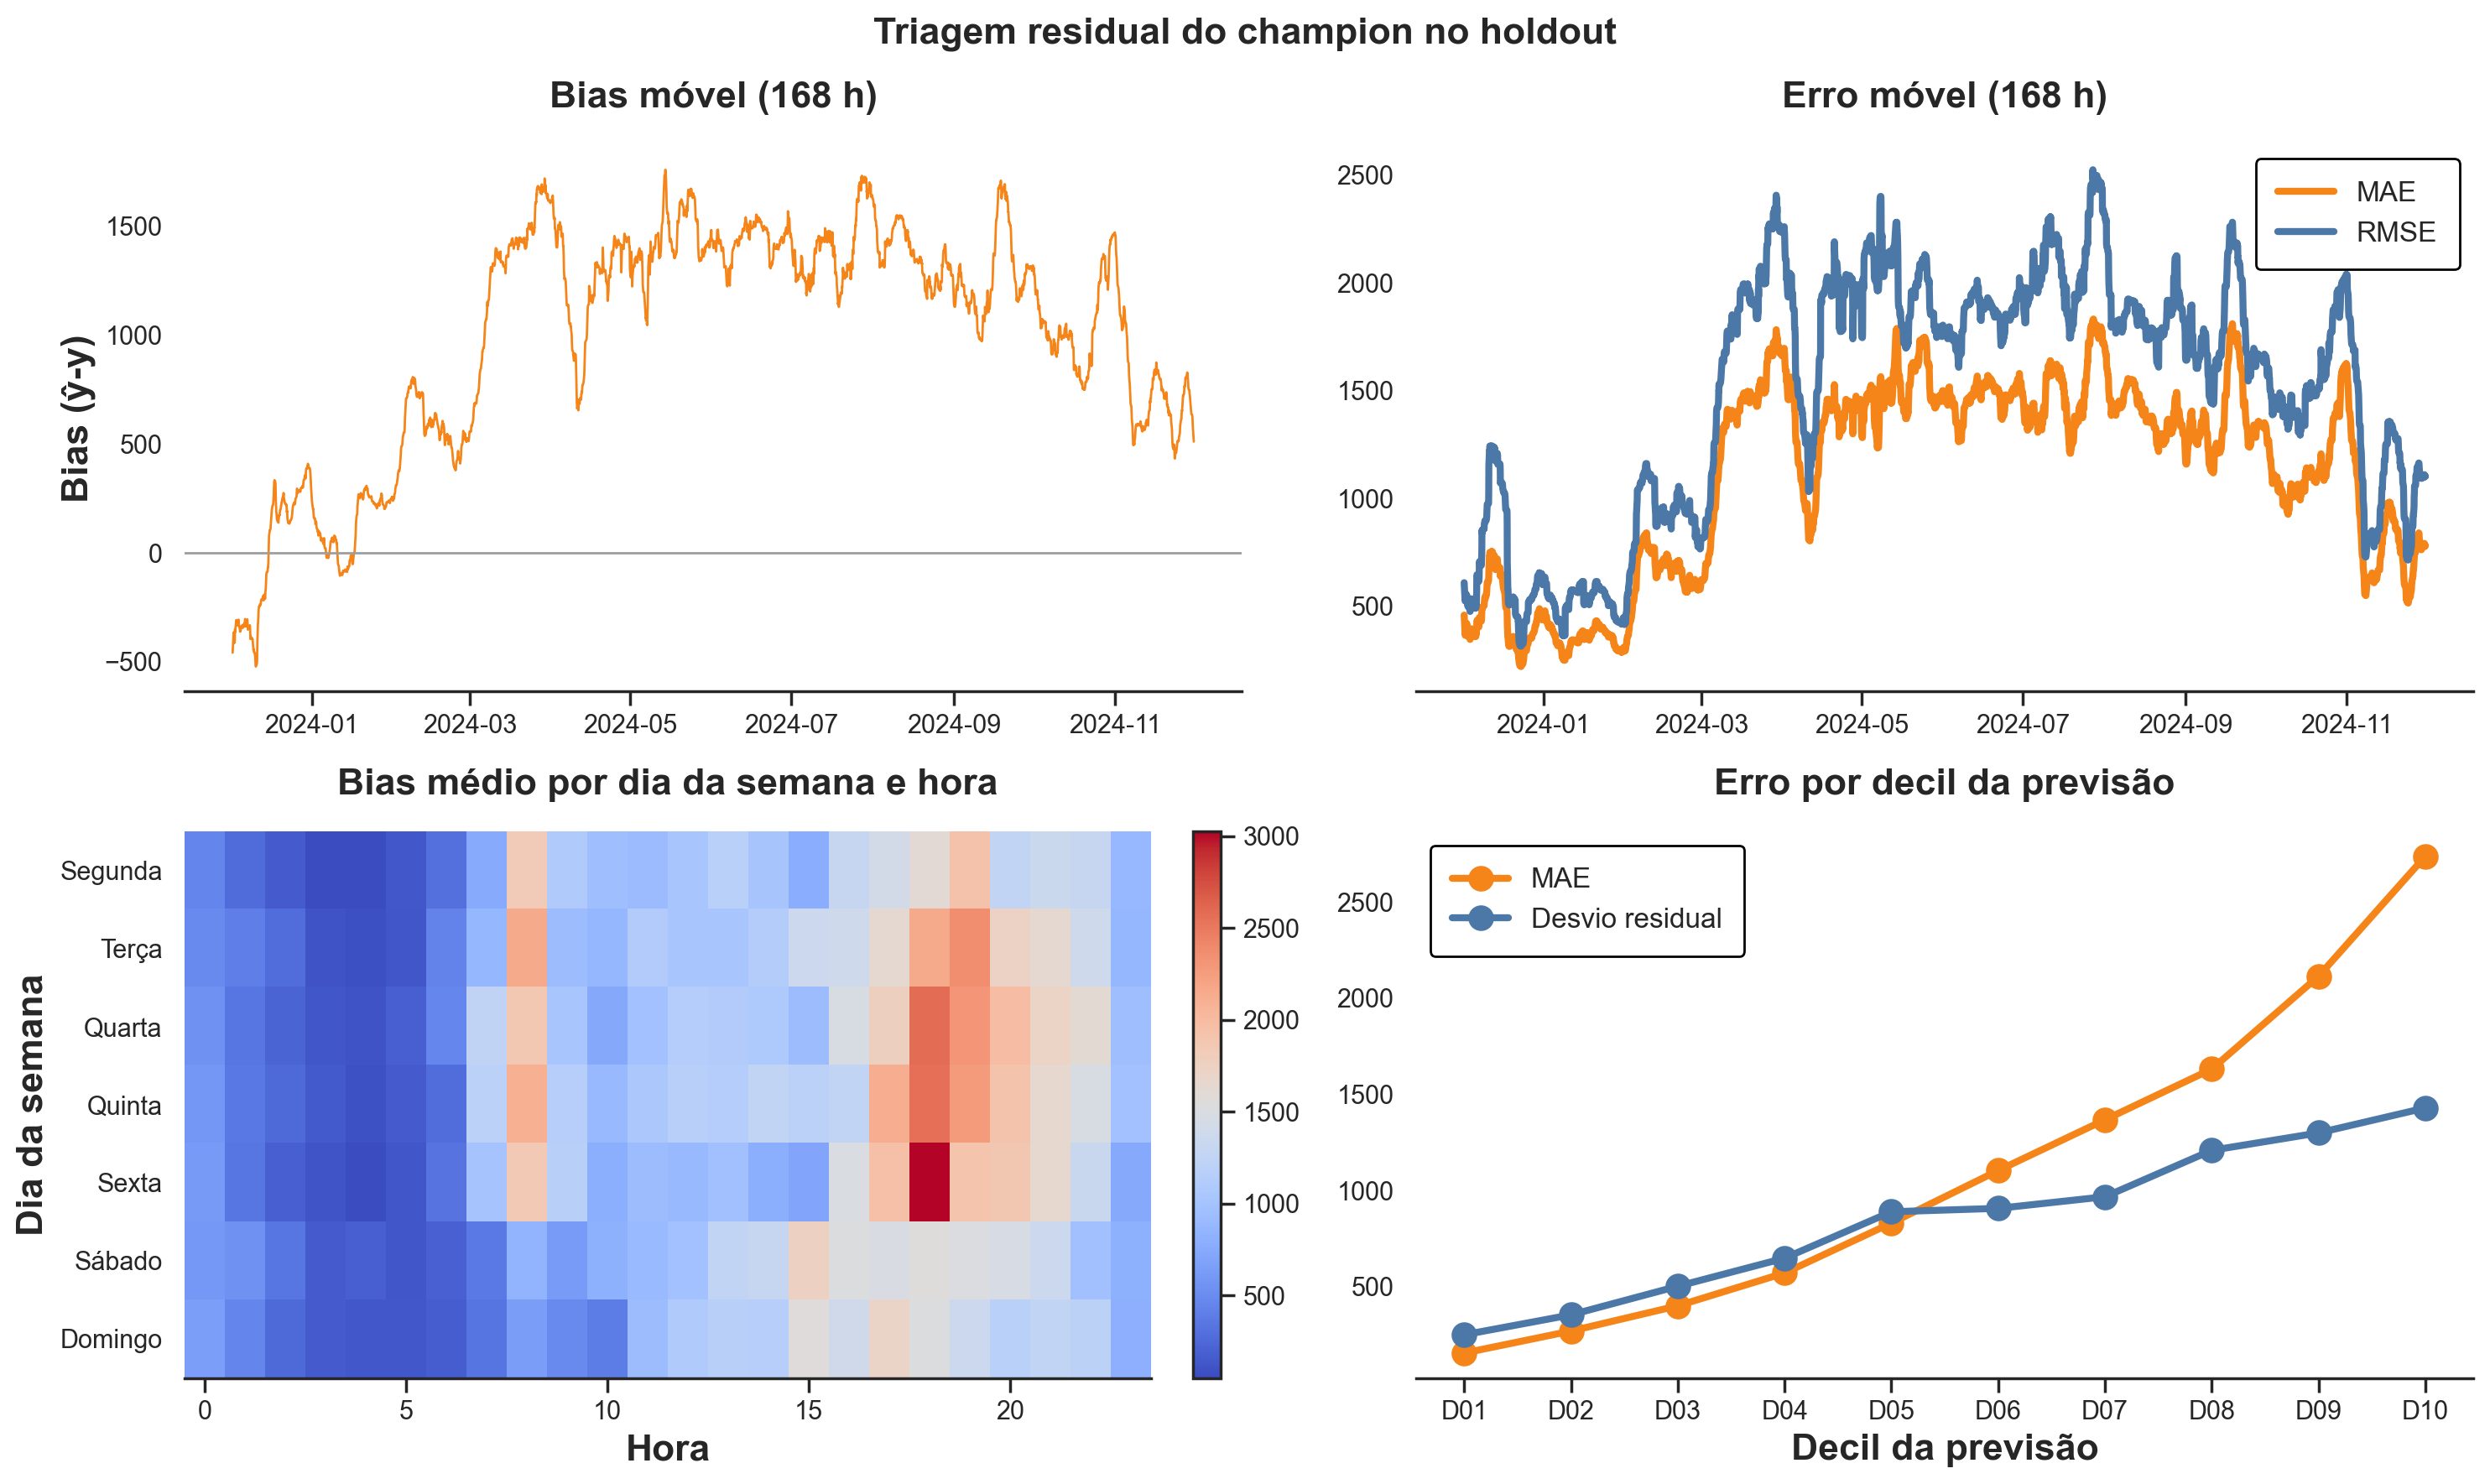

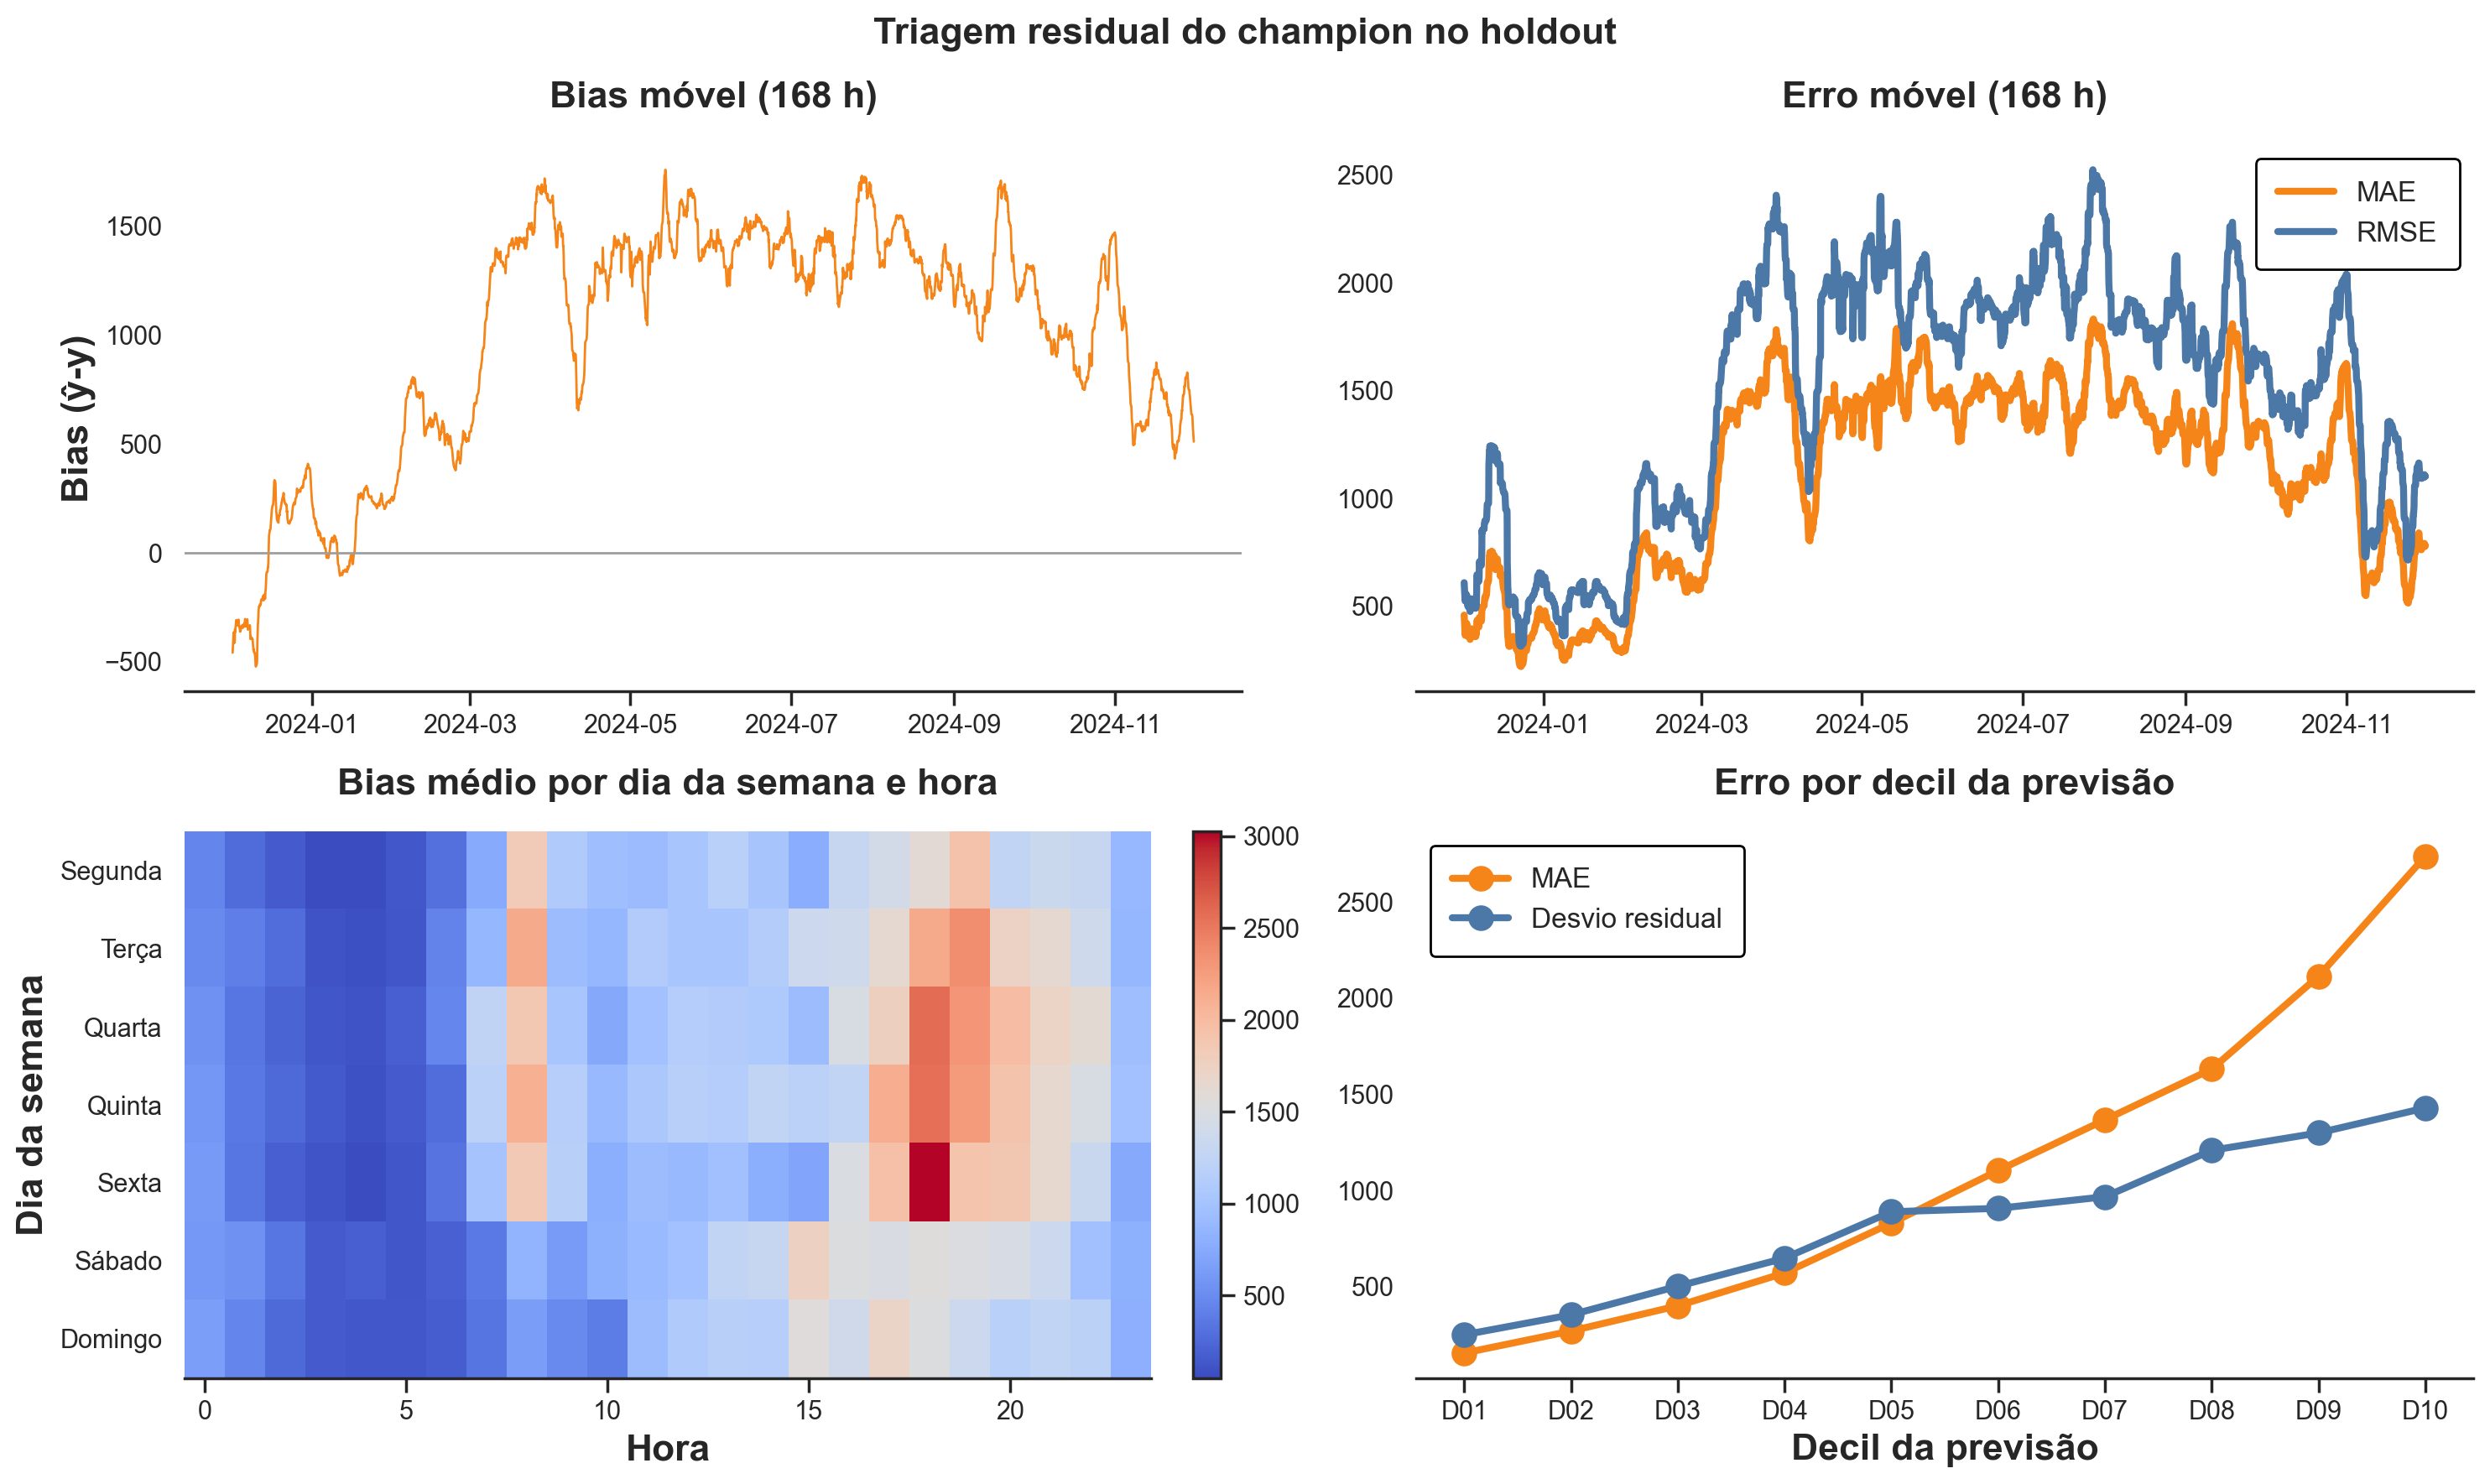

In [20]:
reports.plot_residual_triage(results, lang=lang)


### 7.2 Persistência diária e semanal após padronização

A leitura de heterocedasticidade é separada em quatro versões do resíduo. Primeiro, o resíduo original é mantido como referência. Em seguida, a média residual global é retirada. Depois, é removido o padrão médio por hora da semana, para que a persistência diária e semanal seja avaliada depois do desenviesamento calendárico. Por fim, o resíduo já desenviesado por calendário é dividido por uma escala residual descritiva estimada por estação e decil da previsão.

Essas transformações são estimadas no próprio holdout e têm finalidade exclusivamente descritiva. Elas não representam um calibrador validado, não podem ser anexadas ao modelo atual e não reordenam Champion e Challengers. A redução das estatísticas ARCH e das autocorrelações quadráticas é lida em relação ao resíduo original, sem concluir que o problema foi resolvido apenas porque um p-valor aumentou.


In [21]:
reports.residual_transformation_report(results, lang=lang)


,Versão do resíduo,Lag ARCH,Observações,Observações efetivas,Média,Desvio,Durbin-Watson,ACF lag 1,ACF lag 24,ACF lag 168,...,p-valor ajustado (Holm),Evidência ARCH,Redução ARCH vs. original,Redução ACF lag 24,Redução ACF lag 168,Redução ACF² lag 24,Redução ACF² lag 168,Status,Motivo,Nota diagnóstica
0,Original,24,8784,8760,-1.000095e+03,1256.294481,0.407160,0.667260,0.515381,0.452973,...,abaixo da precisão numérica,Sim,0.000000,0.000000,0.000000e+00,0.000000,0.000000,Aplicável,,Holdout-only descriptive transformation; not a...
1,Original,168,8784,8616,-1.000095e+03,1256.294481,0.407160,0.667260,0.515381,0.452973,...,abaixo da precisão numérica,Sim,0.000000,0.000000,0.000000e+00,0.000000,0.000000,Aplicável,,Holdout-only descriptive transformation; not a...
2,Desenviesado globalmente,24,8784,8760,-1.391577e-13,1256.294481,0.665216,0.667260,0.515381,0.452973,...,8.17e-309,Sim,0.405827,0.000000,1.110223e-16,0.416921,0.451940,Aplicável,,Holdout-only descriptive transformation; not a...
3,Desenviesado globalmente,168,8784,8616,-1.391577e-13,1256.294481,0.665216,0.667260,0.515381,0.452973,...,2.42e-296,Sim,0.367843,0.000000,1.110223e-16,0.416921,0.451940,Aplicável,,Holdout-only descriptive transformation; not a...
4,Sem padrão semanal médio,24,8784,8760,-9.939833e-15,1086.891194,0.765355,0.617208,0.387092,0.263973,...,2.12e-263,Sim,0.488252,0.248921,4.172448e-01,0.531308,0.601460,Aplicável,,Holdout-only descriptive transformation; not a...
5,Sem padrão semanal médio,168,8784,8616,-9.939833e-15,1086.891194,0.765355,0.617208,0.387092,0.263973,...,2.08e-232,Sim,0.474393,0.248921,4.172448e-01,0.531308,0.601460,Aplicável,,Holdout-only descriptive transformation; not a...
6,Padronizado por nível,24,8784,8760,6.202107e-02,0.998402,0.849074,0.573520,0.316571,0.215960,...,3.53e-267,Sim,0.481385,0.385754,5.232383e-01,0.702704,0.691323,Aplicável,,Holdout-only descriptive transformation; not a...
7,Padronizado por nível,168,8784,8616,6.202107e-02,0.998402,0.849074,0.573520,0.316571,0.215960,...,6.31e-226,Sim,0.485321,0.385754,5.232383e-01,0.702704,0.691323,Aplicável,,Holdout-only descriptive transformation; not a...


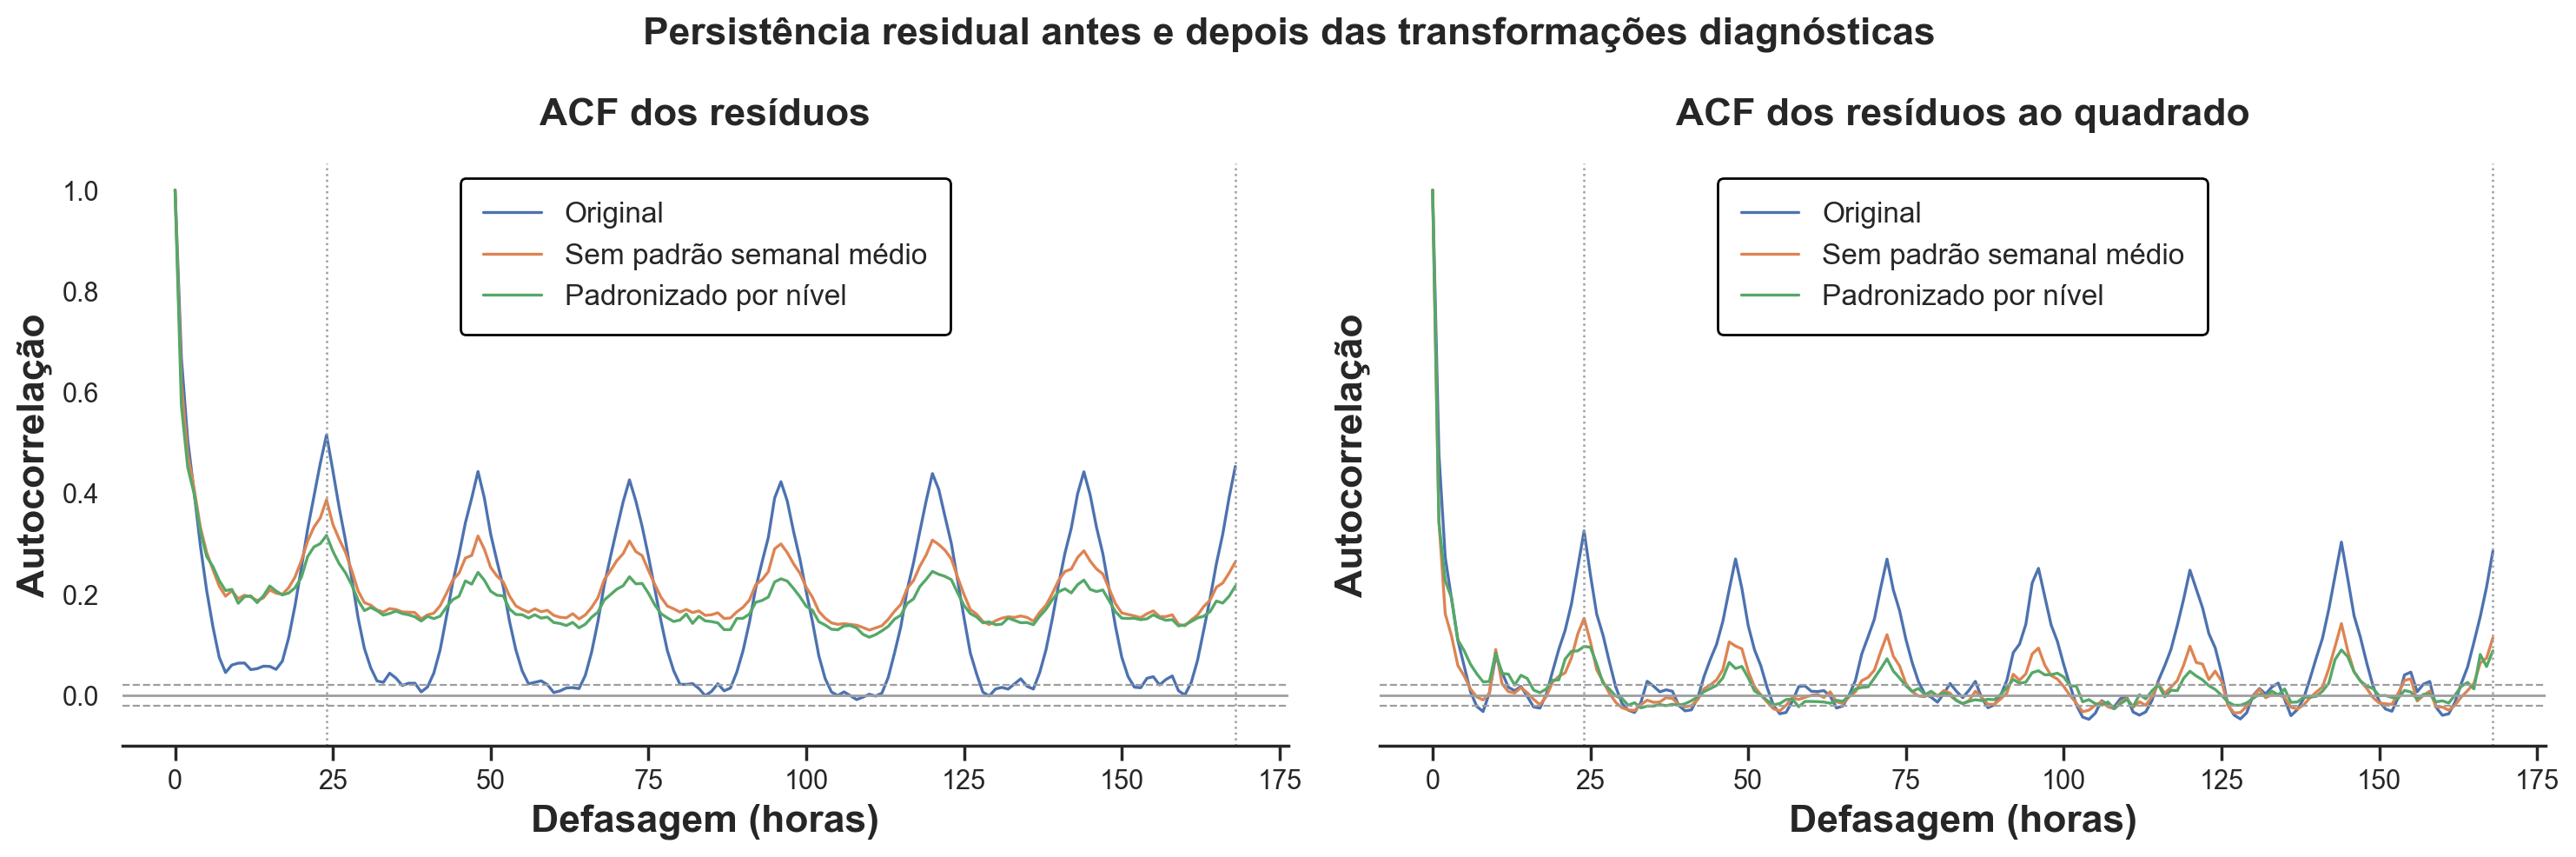

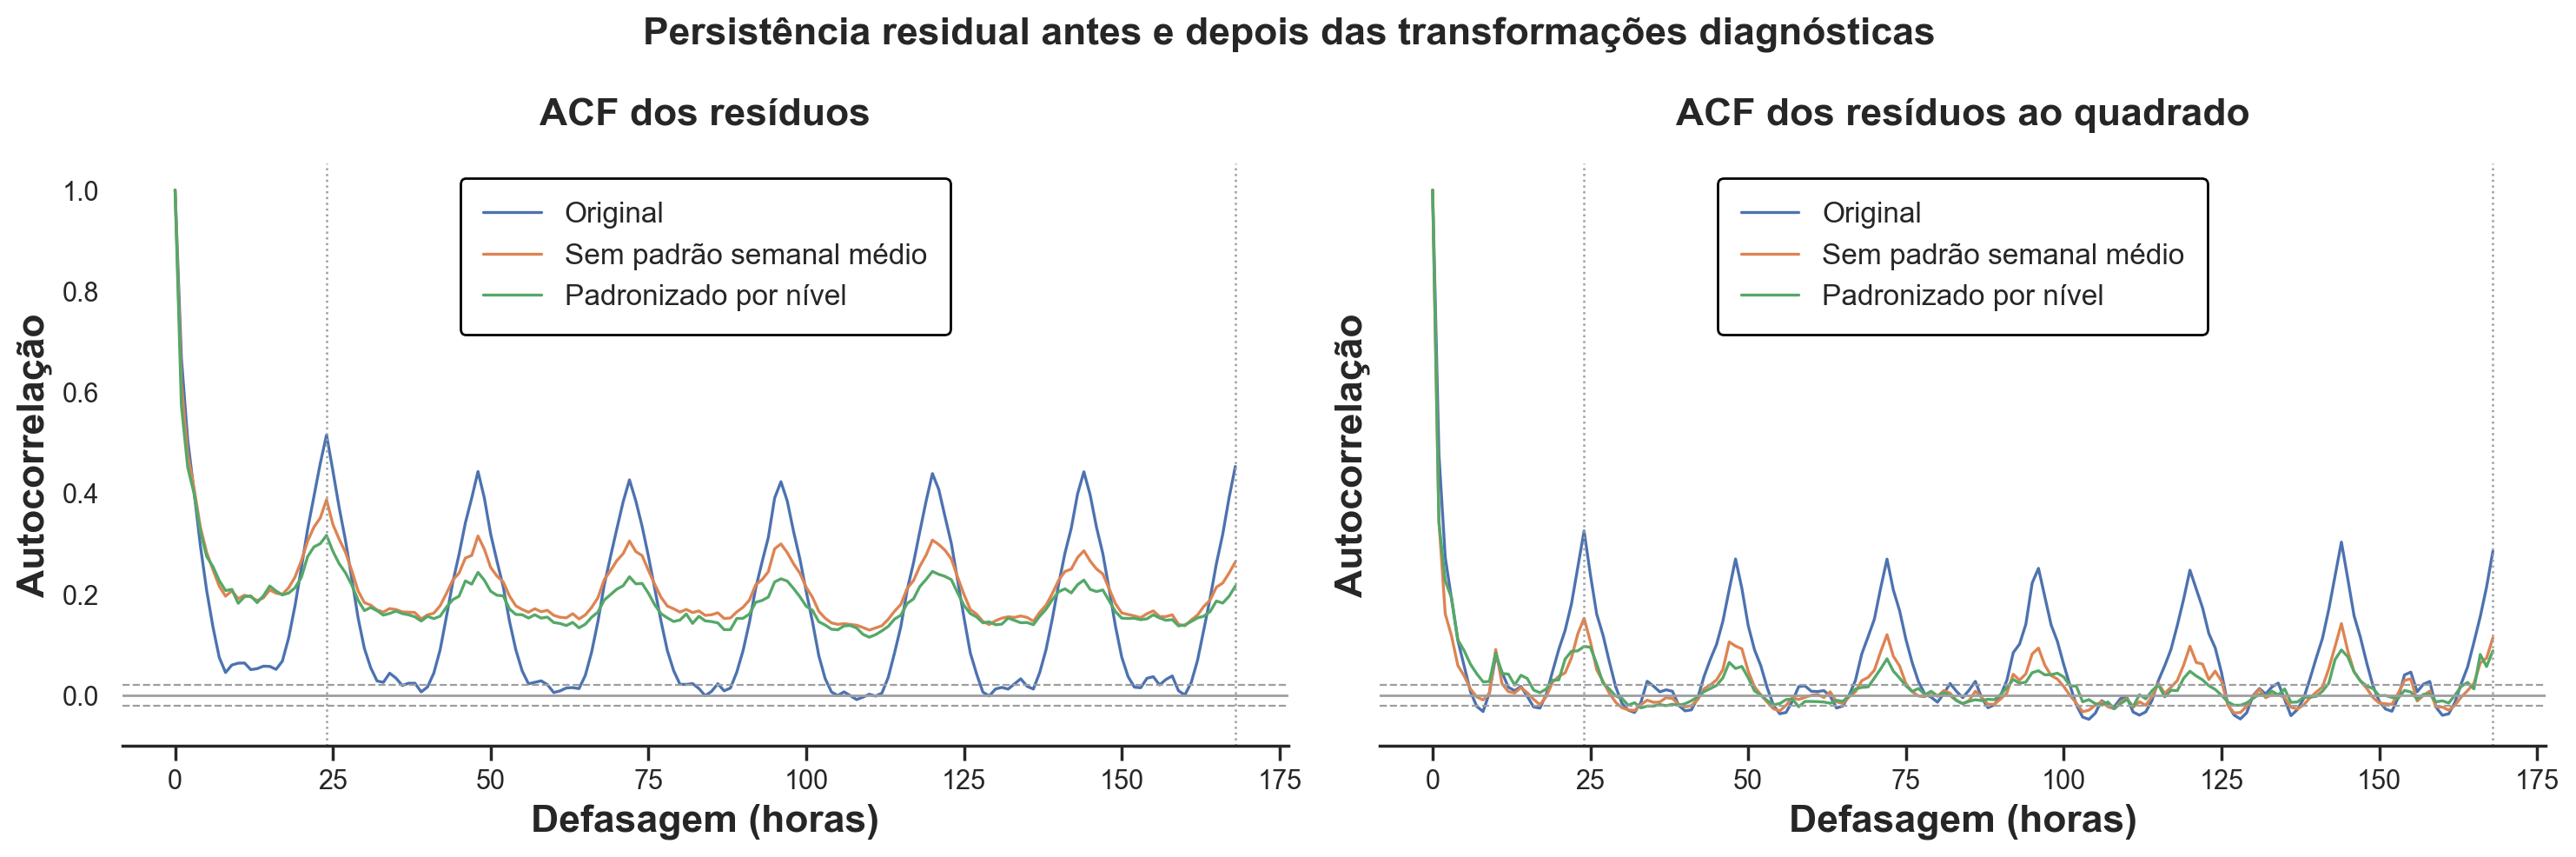

In [22]:
reports.plot_residual_transformation_acf(results, lang=lang)


In [23]:
reports.residual_handoff_message(results, lang=lang)


'A triagem residual indica deslocamento predominante para superestimação; o |bias| representa 89.4% do MAE do champion. Após a retirada do padrão médio semanal, a autocorrelação no lag 168 foi reduzida em 41.7%; após a padronização por nível previsto, o indicador ARCH médio foi reduzido em 48.3%, mas a evidência de agrupamento condicional permaneceu. O CatBoost continua confirmado apenas como melhor previsão pontual sob o protocolo vigente; intervalos sob hipótese IID ainda não foram validados.'

> ### Insight
>
> A confirmação do CatBoost como melhor previsão pontual não é revogada pela heterocedasticidade residual. A evidência indica que a escala do erro varia com o nível previsto e que os resíduos permanecem dependentes no tempo; portanto, o ranking confirmatório é mantido, mas a interpretação probabilística dos erros ainda deve ser tratada com cautela.
>
> O viés e a autocorrelação da média residual devem receber prioridade antes que ARCH/GARCH seja adotado. Intervalos de previsão sob hipótese IID não são considerados confiáveis neste estágio, e lags ou médias móveis só poderão ser avaliados em uma futura versão quando a disponibilidade for compatível com o horizonte de previsão e sem leakage. Qualquer nova versão deverá ser validada no backtesting de desenvolvimento e, posteriormente, em uma nova janela independente.


## 8. Resíduos por condições operacionais

As métricas são segmentadas por estação, mês, hora, dia útil ou fim de semana, feriado, dia de
funcionamento, período de pico, faixas de temperatura, frio extremo, calor extremo e quantis da
demanda observada. As condições anteriormente frágeis recebem atenção explícita, em particular o
outono, o calor extremo e os períodos de alta demanda, nos quais grandes subestimações foram
observadas em etapas anteriores. As contagens de cada segmento são preservadas, de modo que nenhuma
observação é descartada ou contada duas vezes.

In [24]:
reports.condition_metrics_report(results, 'season', lang=lang)

,Segmento,Estimator,Papel,Observações,MAE,RMSE,WAPE,Bias médio (ŷ−y)
0,Inverno,CatBoostRegressor,Champion,2184,492.493188,762.963155,0.180001,254.275627
1,Primavera,CatBoostRegressor,Champion,2208,1425.297500,1911.093953,0.256486,1364.525281
2,Verão,CatBoostRegressor,Champion,2208,1441.173503,1936.311179,0.259855,1384.402061
3,Outono,CatBoostRegressor,Champion,2184,1106.457775,1518.149521,0.199833,988.947960
4,Inverno,HistGradientBoostingRegressor,Challenger,2184,559.039204,822.359664,0.204323,265.352071
5,Primavera,HistGradientBoostingRegressor,Challenger,2208,1212.083966,1736.793195,0.218118,1113.750257
6,Verão,HistGradientBoostingRegressor,Challenger,2208,2302.996648,2953.085896,0.415249,2224.533430
7,Outono,HistGradientBoostingRegressor,Challenger,2184,1617.996211,2164.874219,0.292219,1503.402362
8,Inverno,RandomForestRegressor,Challenger,2184,668.590948,929.485656,0.244363,431.257205
9,Primavera,RandomForestRegressor,Challenger,2208,1530.590787,2238.929349,0.275434,1370.380379


2026-07-31 11:41:56,446 — matplotlib.category — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-31 11:41:56,448 — matplotlib.category — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


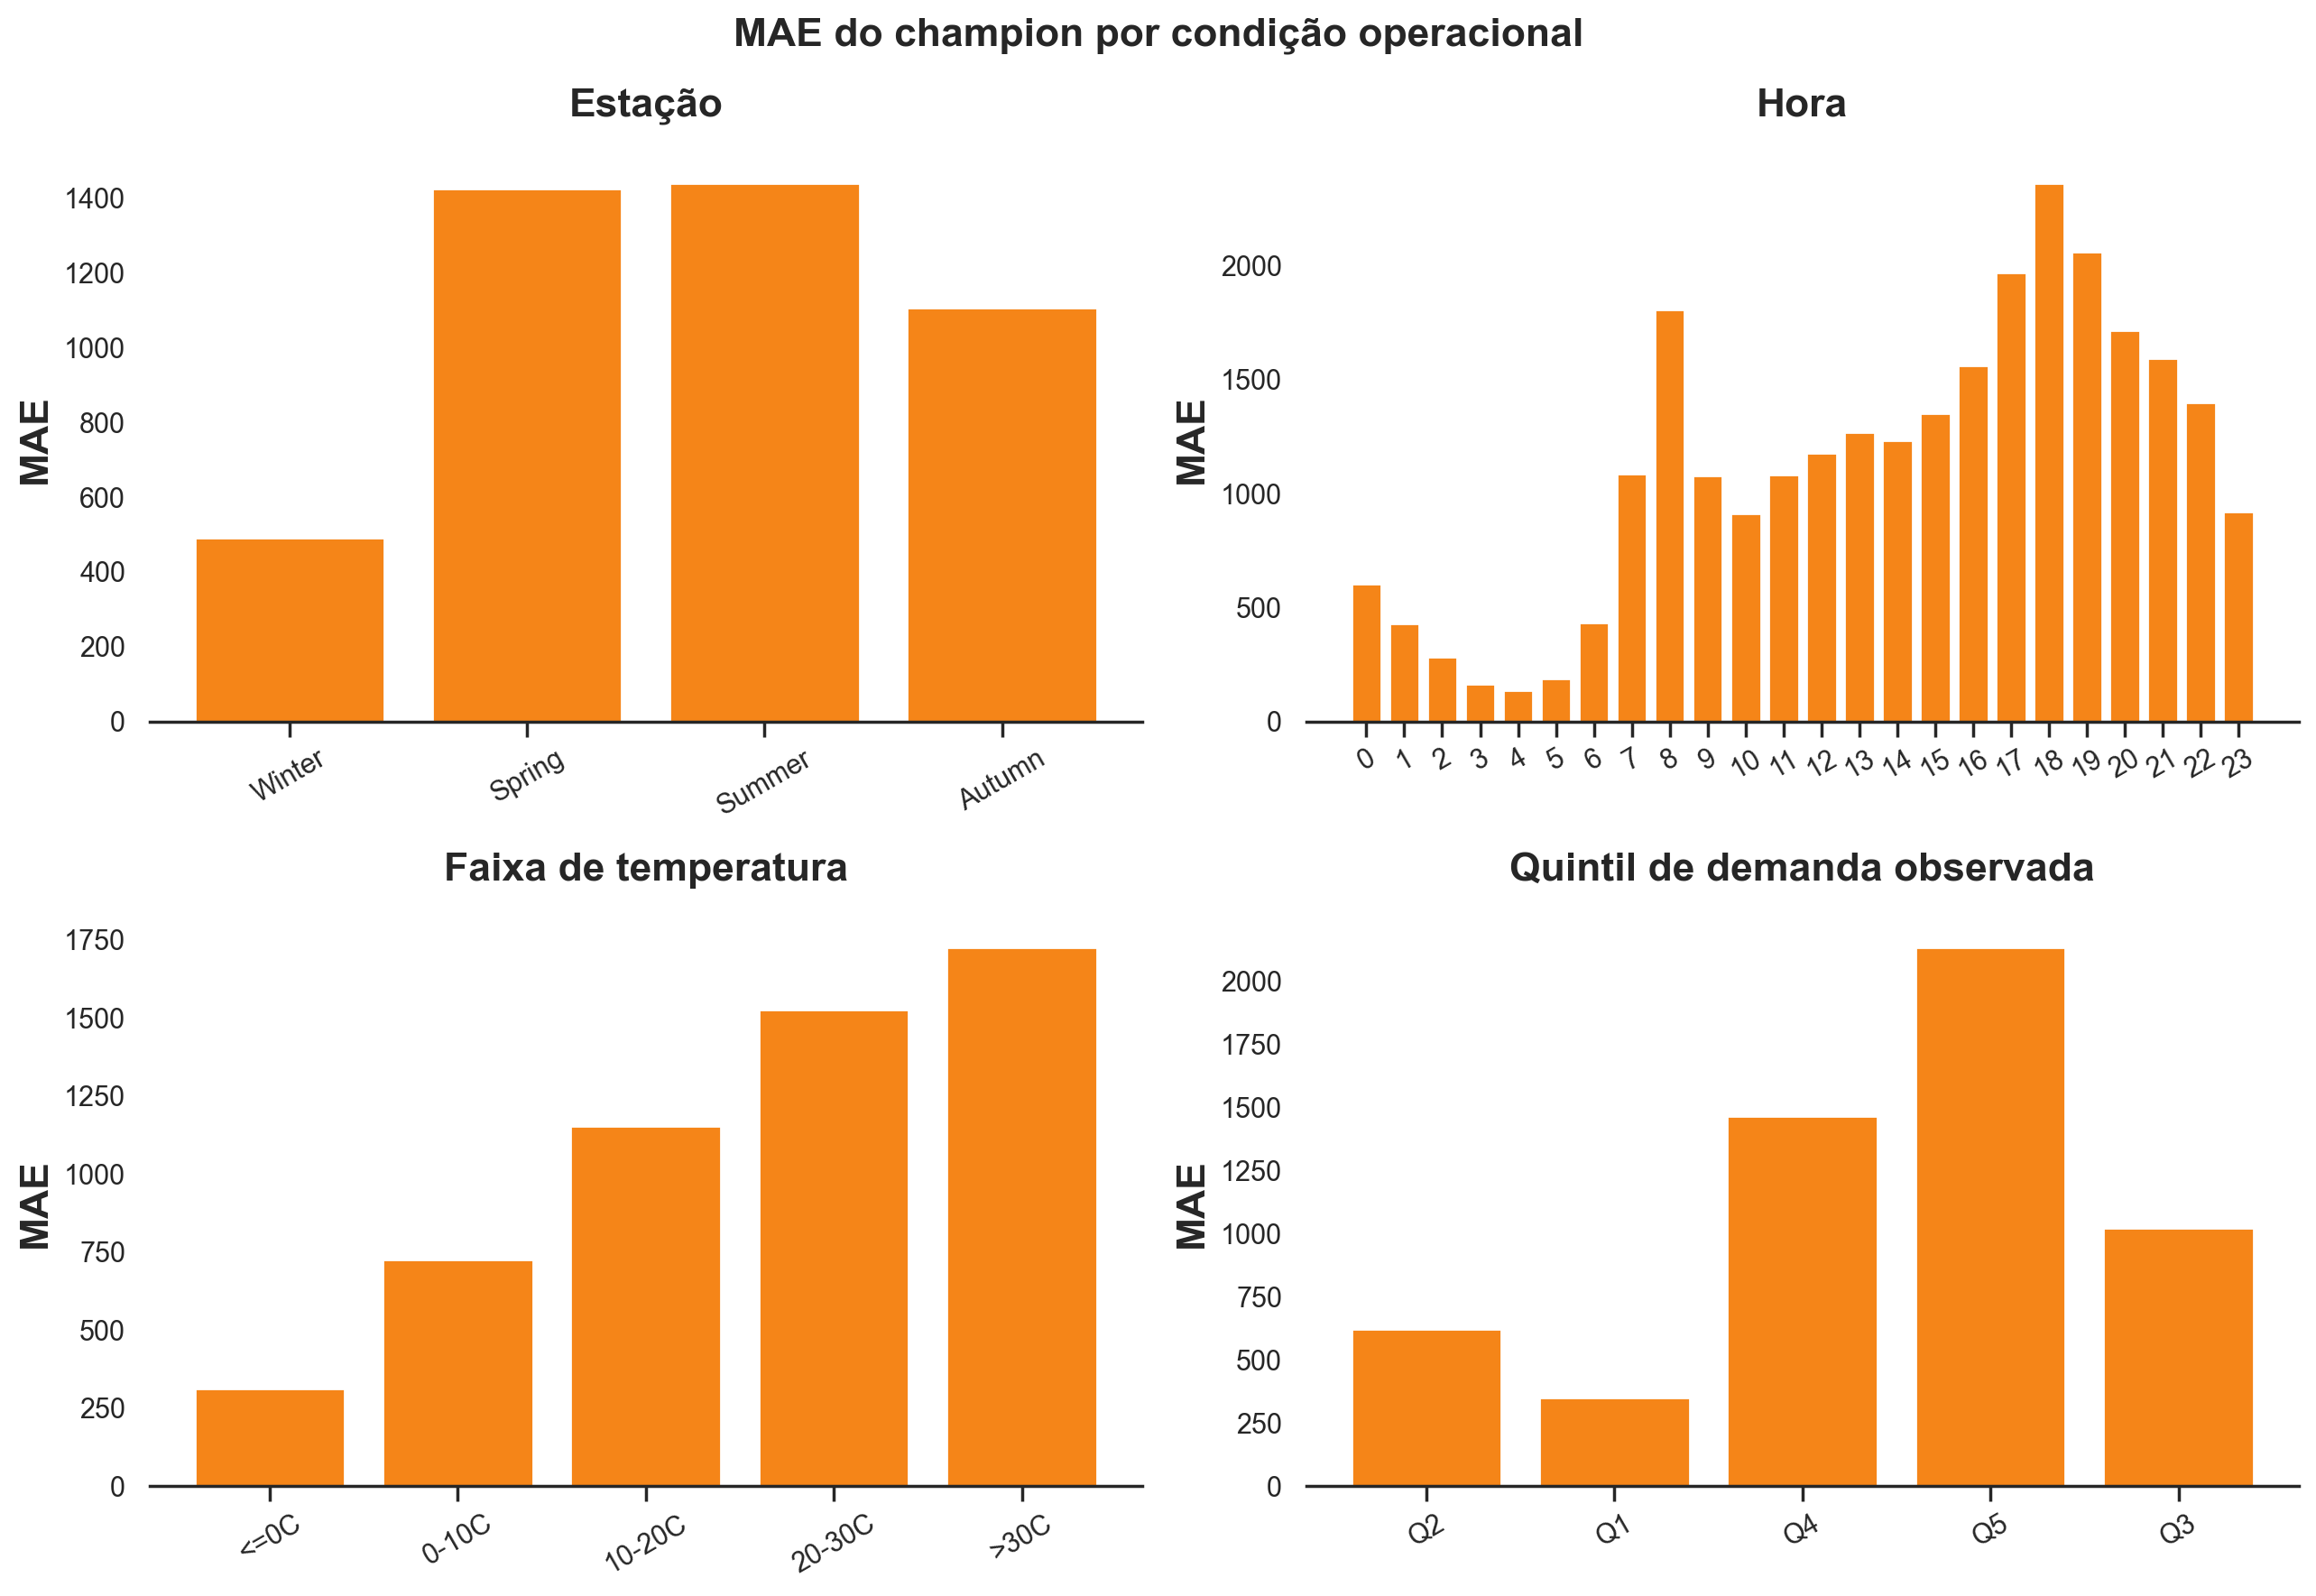

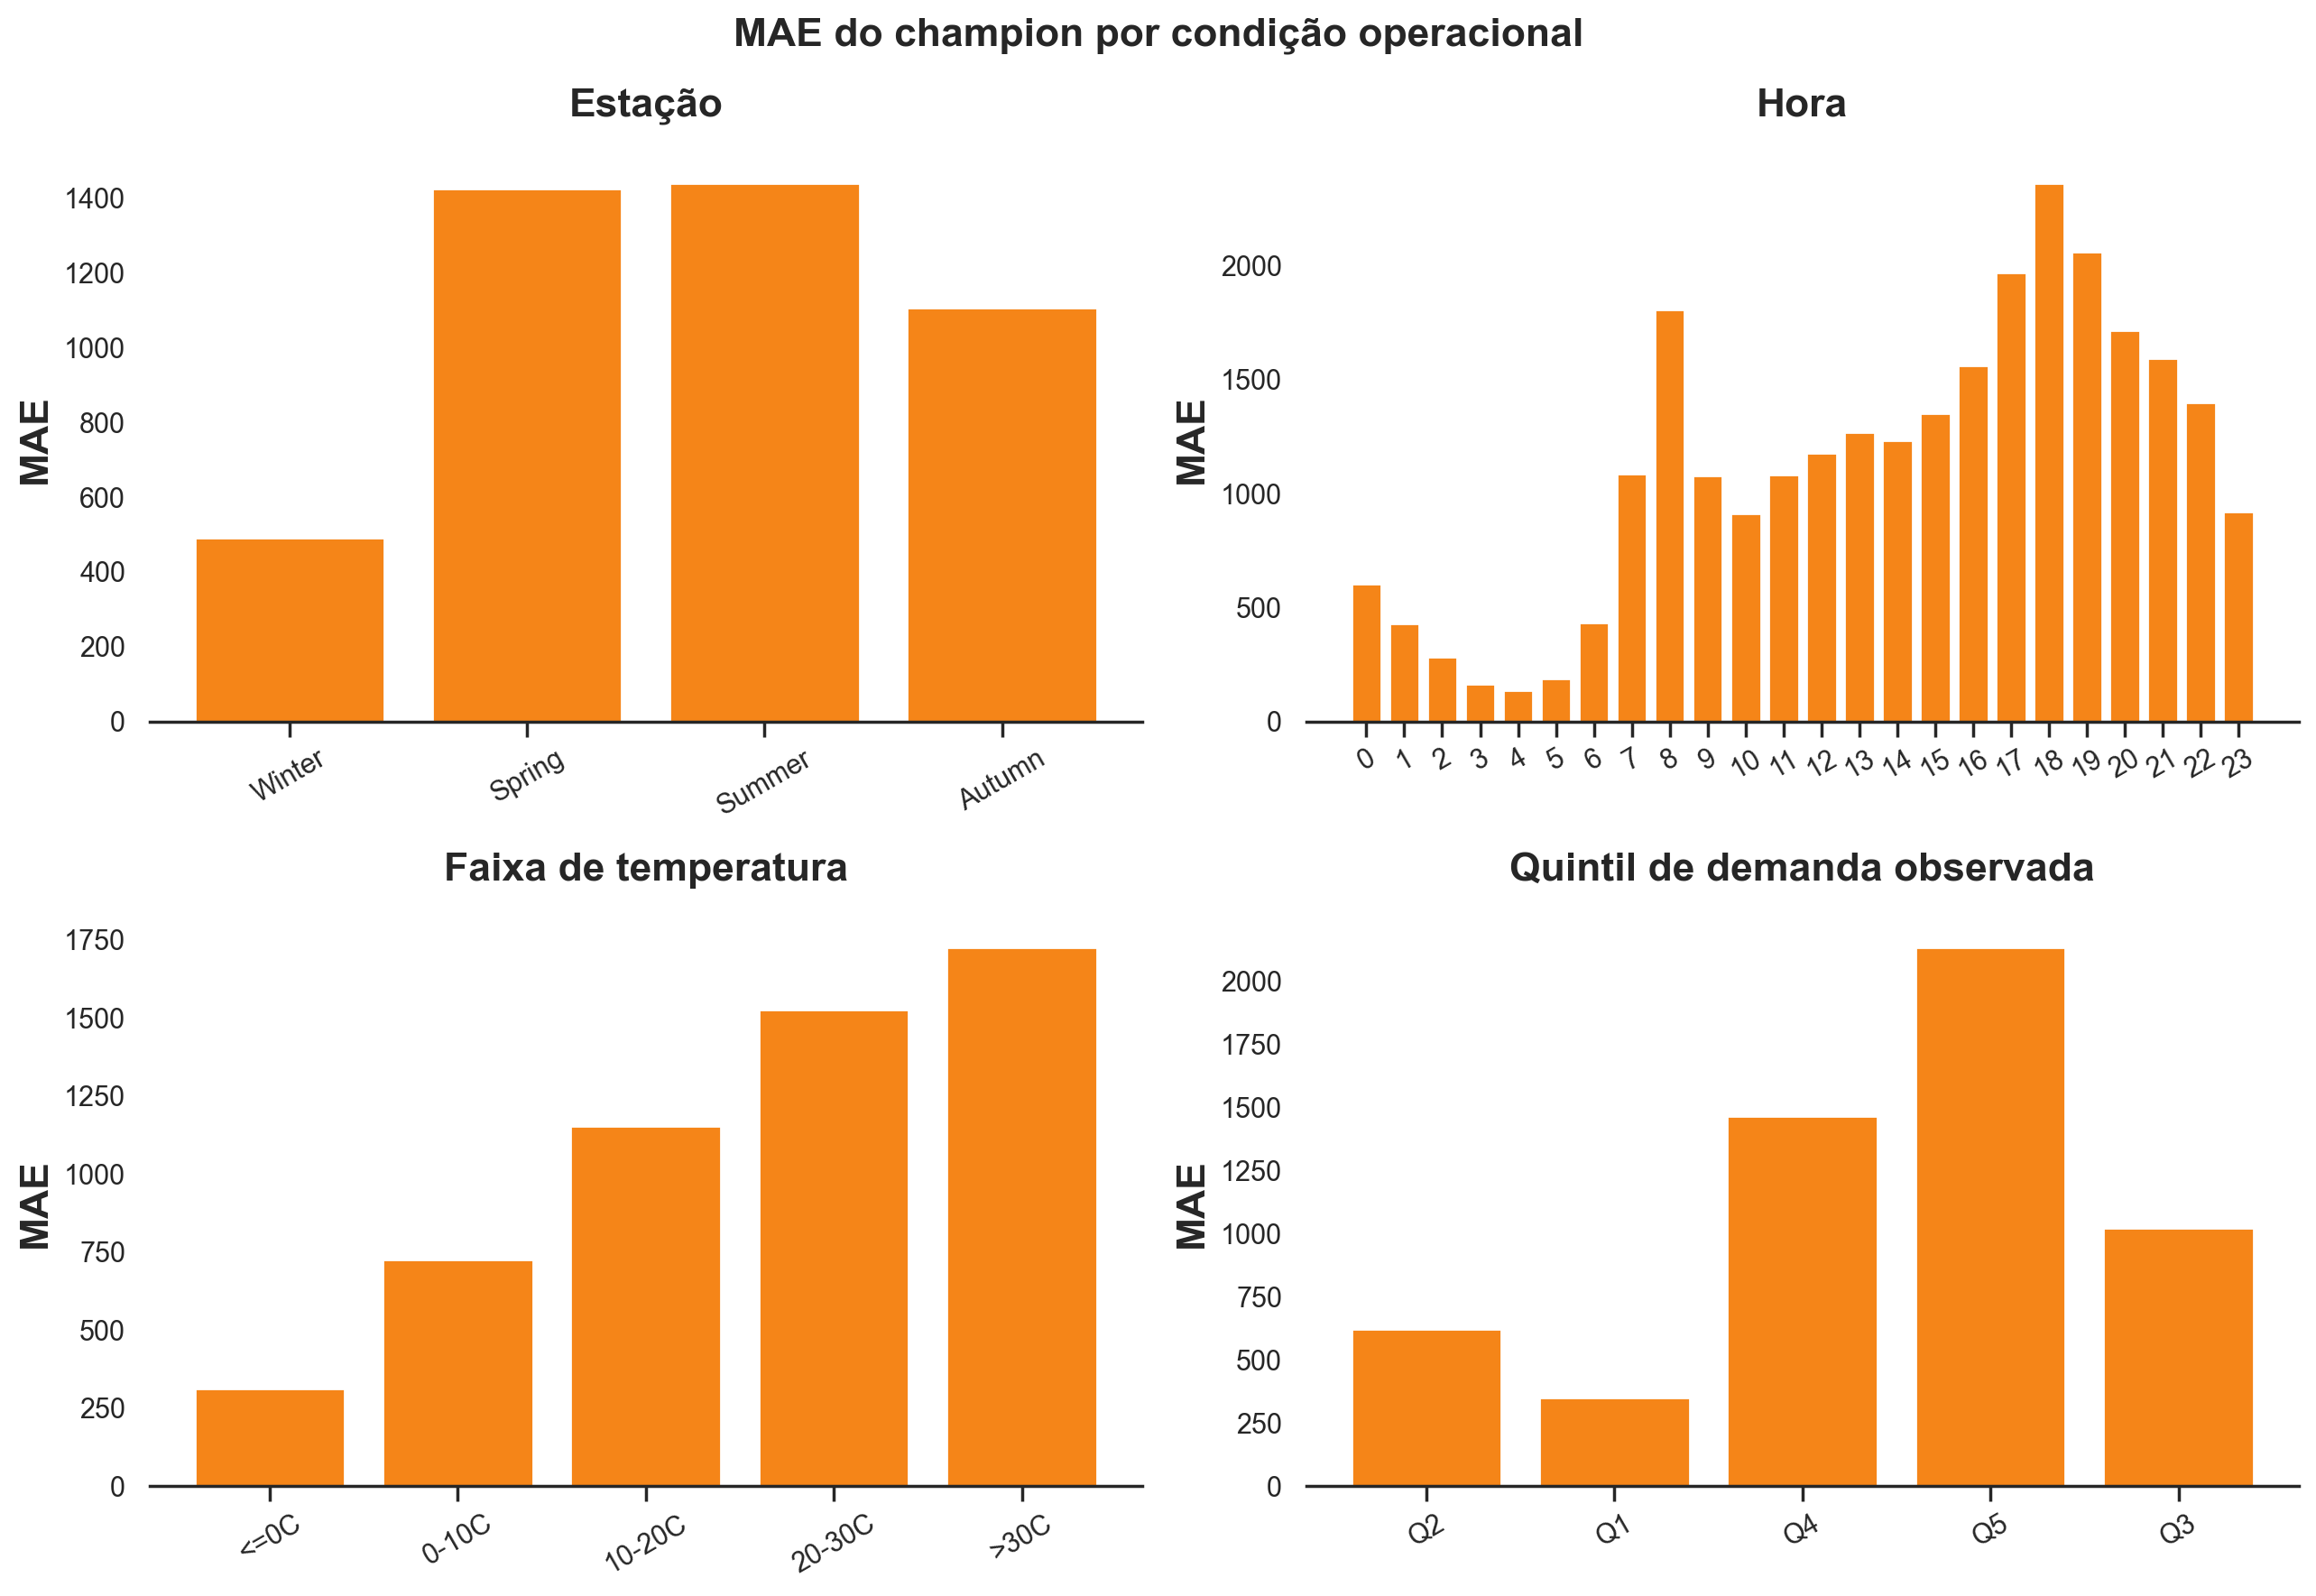

In [25]:
reports.plot_condition_metrics(results, lang=lang)

## 9. Decomposição da previsão e metodologia SHAP

A previsão de cada candidato é decomposta como log1p da previsão igual à baseline temporal robusta
somada à previsão do modelo de resíduos. Os valores SHAP explicam a previsão do modelo de resíduos na
escala logarítmica residual e não são diretamente aditivos na escala de bicicletas por hora, por causa
da transformação expm1. Duas identidades são verificadas com tolerância numérica rigorosa: o valor
esperado somado à soma dos valores SHAP reconstrói a previsão do estimator núcleo, e a reconstrução a
partir da baseline mais o resíduo reproduz a previsão do pipeline externo. Qualquer falha de
aditividade interrompe o fluxo. Os valores SHAP explicam o comportamento do modelo, e não relações
causais, e features correlacionadas podem compartilhar ou redistribuir atribuições.

In [26]:
shap_results = run_shap_validation(results, config)
reports.shap_methodology_report(lang=lang)

CONDA_PREFIX\lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
CONDA_PREFIX\lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
CONDA_PREFIX\lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call r

,Item,Valor
0,Decomposição da previsão,log1p(previsão) = baseline temporal robusta + ...
1,O que os valores SHAP explicam,a previsão do modelo de resíduos na escala log...
2,Escala de aditividade,escala logarítmica residual
3,Não aditivo diretamente em,"bicicletas/hora, por causa da transformação expm1"
4,Identidade verificada (1),expected_value + Σ SHAP ≈ previsão do estimato...
5,Identidade verificada (2),"clip(expm1(baseline + resíduo), 0) ≈ previsão ..."
6,Tolerância numérica,"rtol=1e-6, atol=1e-6"
7,Limitação de interpretação,"os valores explicam o comportamento do modelo,..."


In [27]:
reports.shap_additivity_report(shap_results, lang=lang)

,Papel,Estimator,Observações na amostra,Features transformadas,Erro máx. de aditividade,Erro máx. de reconstrução
0,Champion,CatBoostRegressor,500,41,5.773160e-15,0.000000e+00
1,Challenger,HistGradientBoostingRegressor,500,41,1.110223e-14,0.000000e+00
2,Challenger,RandomForestRegressor,500,25,1.079137e-13,4.365575e-11


## 10. Importância SHAP global

A importância global é apresentada tanto por feature transformada quanto agrupada por feature
conceitual. Para o ranking agrupado, as contribuições das expansões periódicas de uma mesma feature
são somadas por observação antes de se calcular a média do valor absoluto, o que preserva a direção e
a aditividade dentro de cada grupo. As principais features conceituais são também comparadas entre os
três candidatos.

In [28]:
reports.shap_grouped_report(shap_results, lang=lang)

,Feature conceitual,|SHAP| médio (agrupado)
0,Hour,0.341607
1,Elapsed_Hours,0.304019
2,Month,0.173192
3,Time_Period,0.133843
4,Temperature(C),0.116347
5,Rainfall Cat,0.099444
6,Humidity(%),0.092603
7,Rush_Hour,0.081666
8,Cloud Cover (oktas),0.072296
9,Rush_Period,0.063275


In [29]:
reports.shap_detailed_report(shap_results, lang=lang)

,Feature transformada,|SHAP| médio
0,Elapsed_Hours,0.304019
1,Hour_spline_03,0.230632
2,Time_Period,0.133843
3,Temperature(C),0.116347
4,Rainfall Cat,0.099444
5,Hour_spline_02,0.093387
6,Humidity(%),0.092603
7,Rush_Hour,0.081666
8,Cloud Cover (oktas),0.072296
9,Hour_spline_10,0.069242


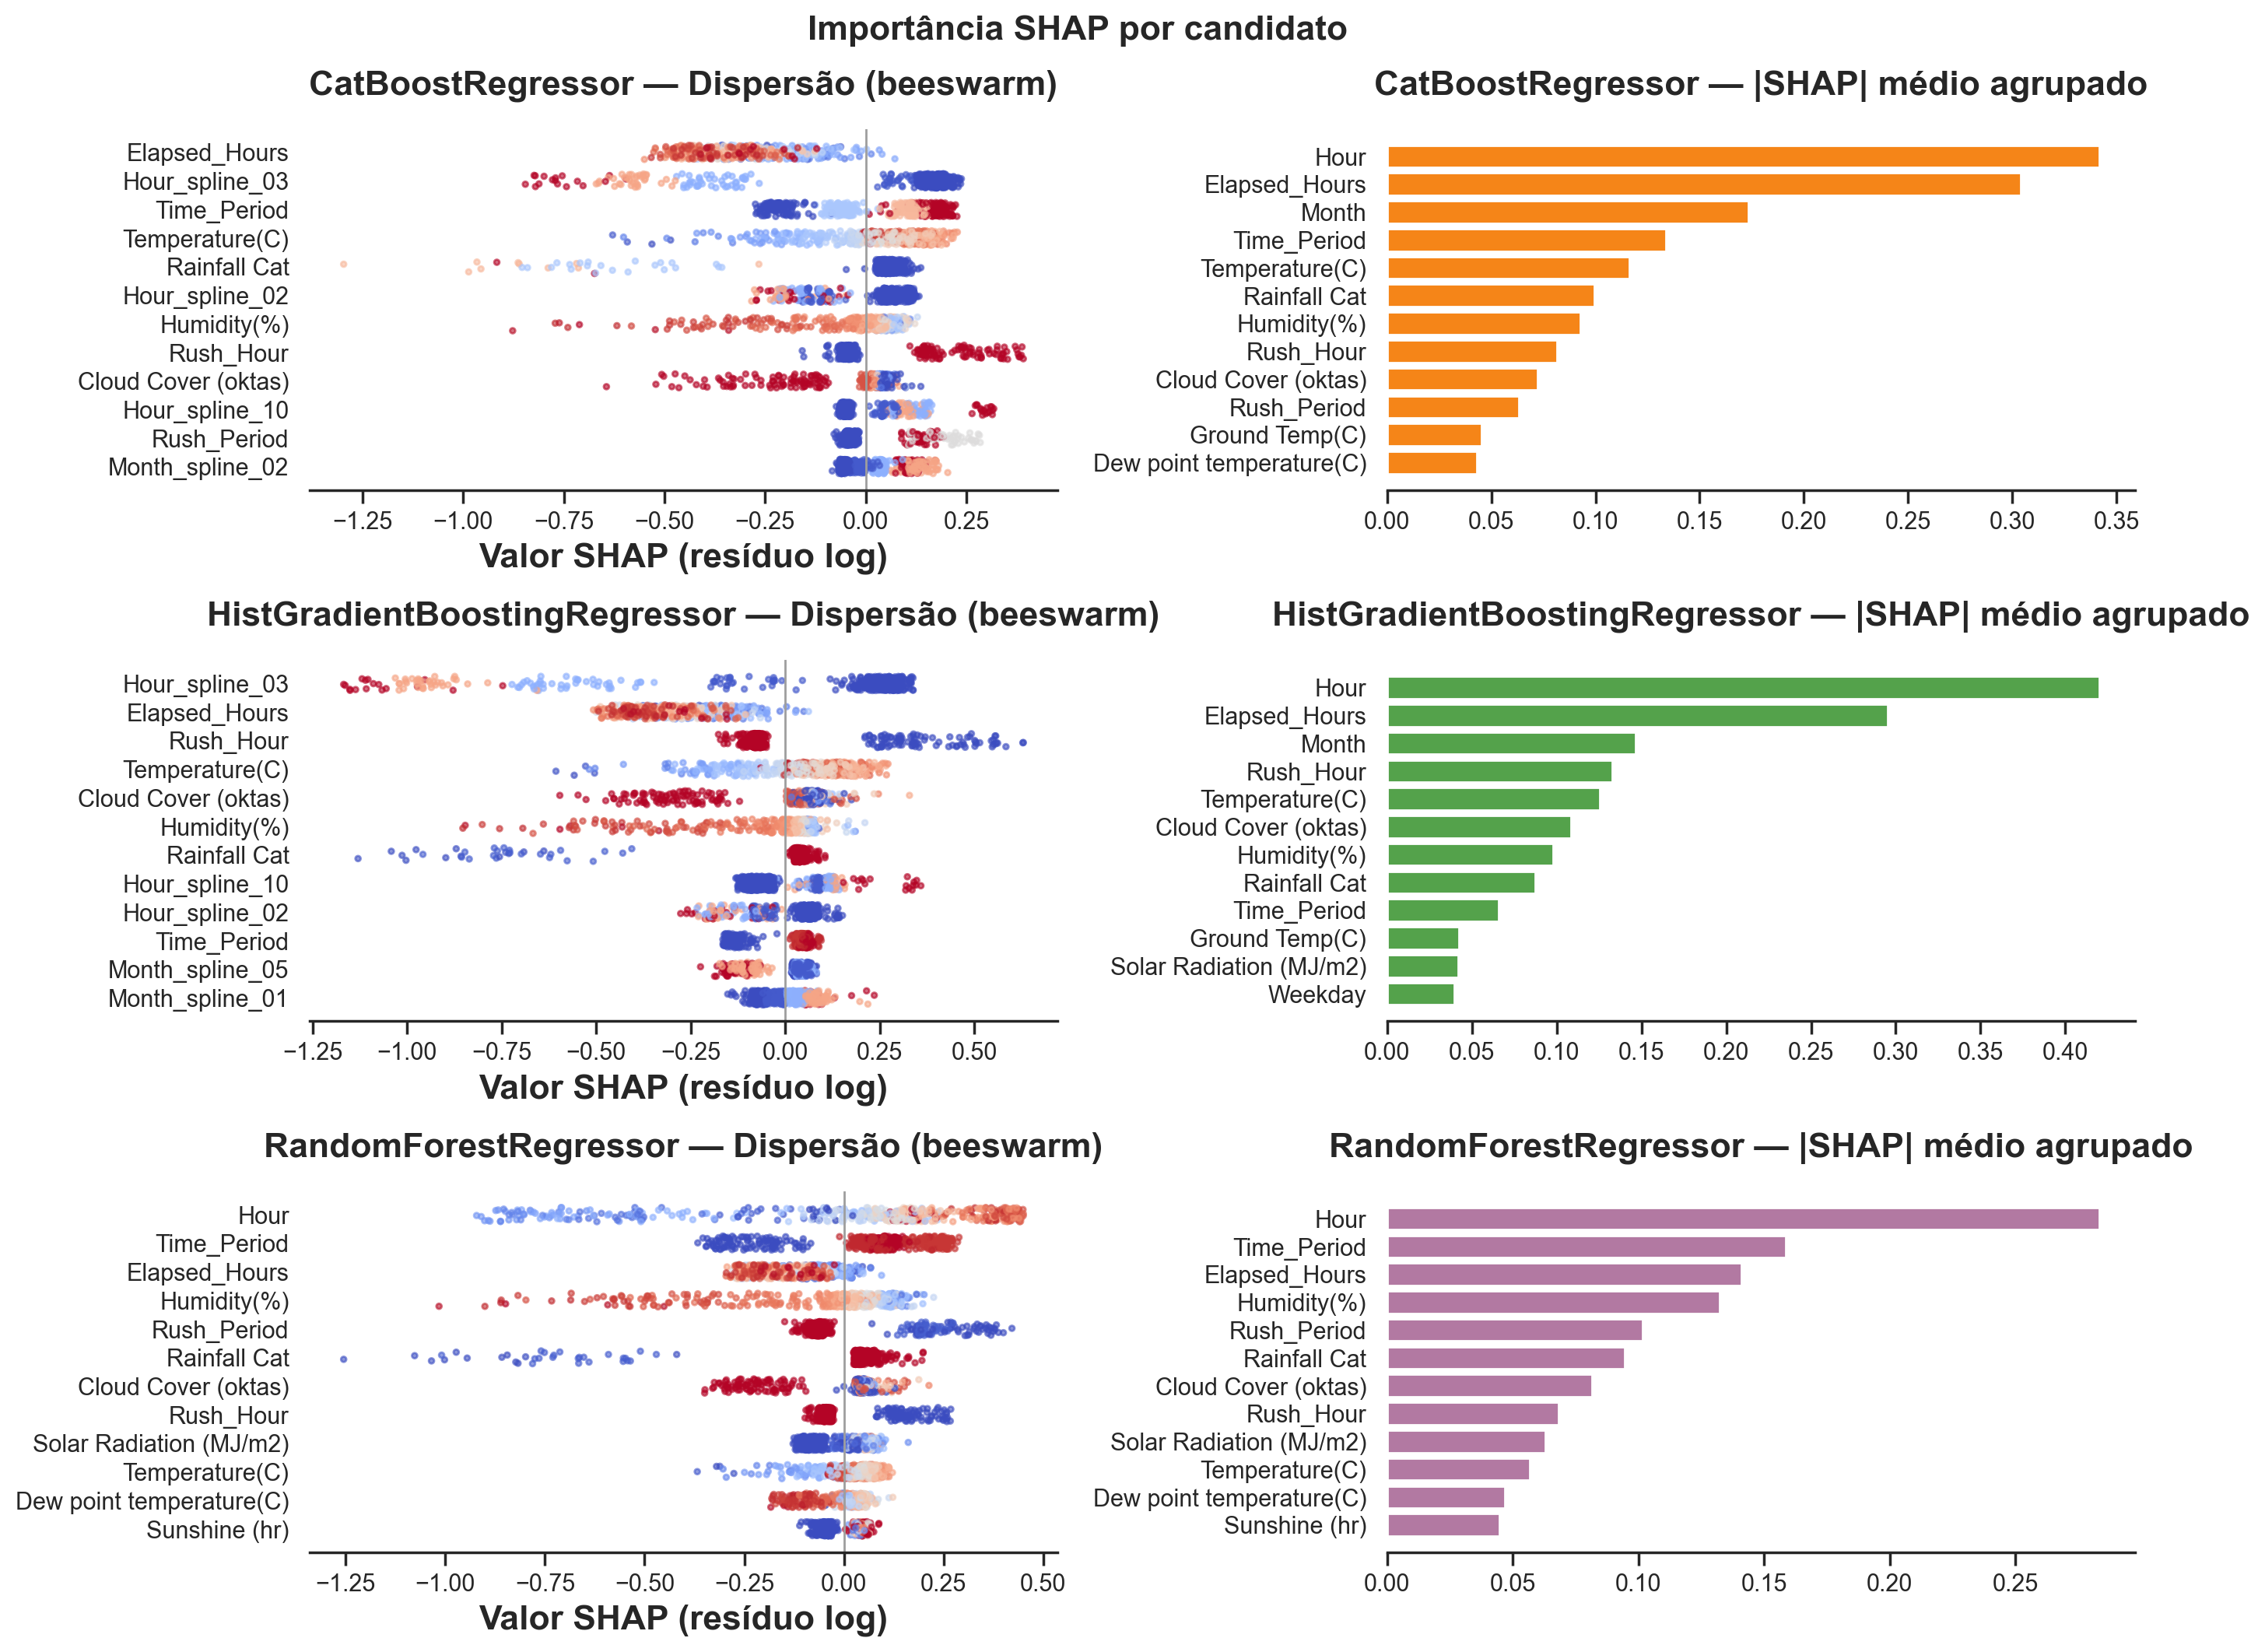

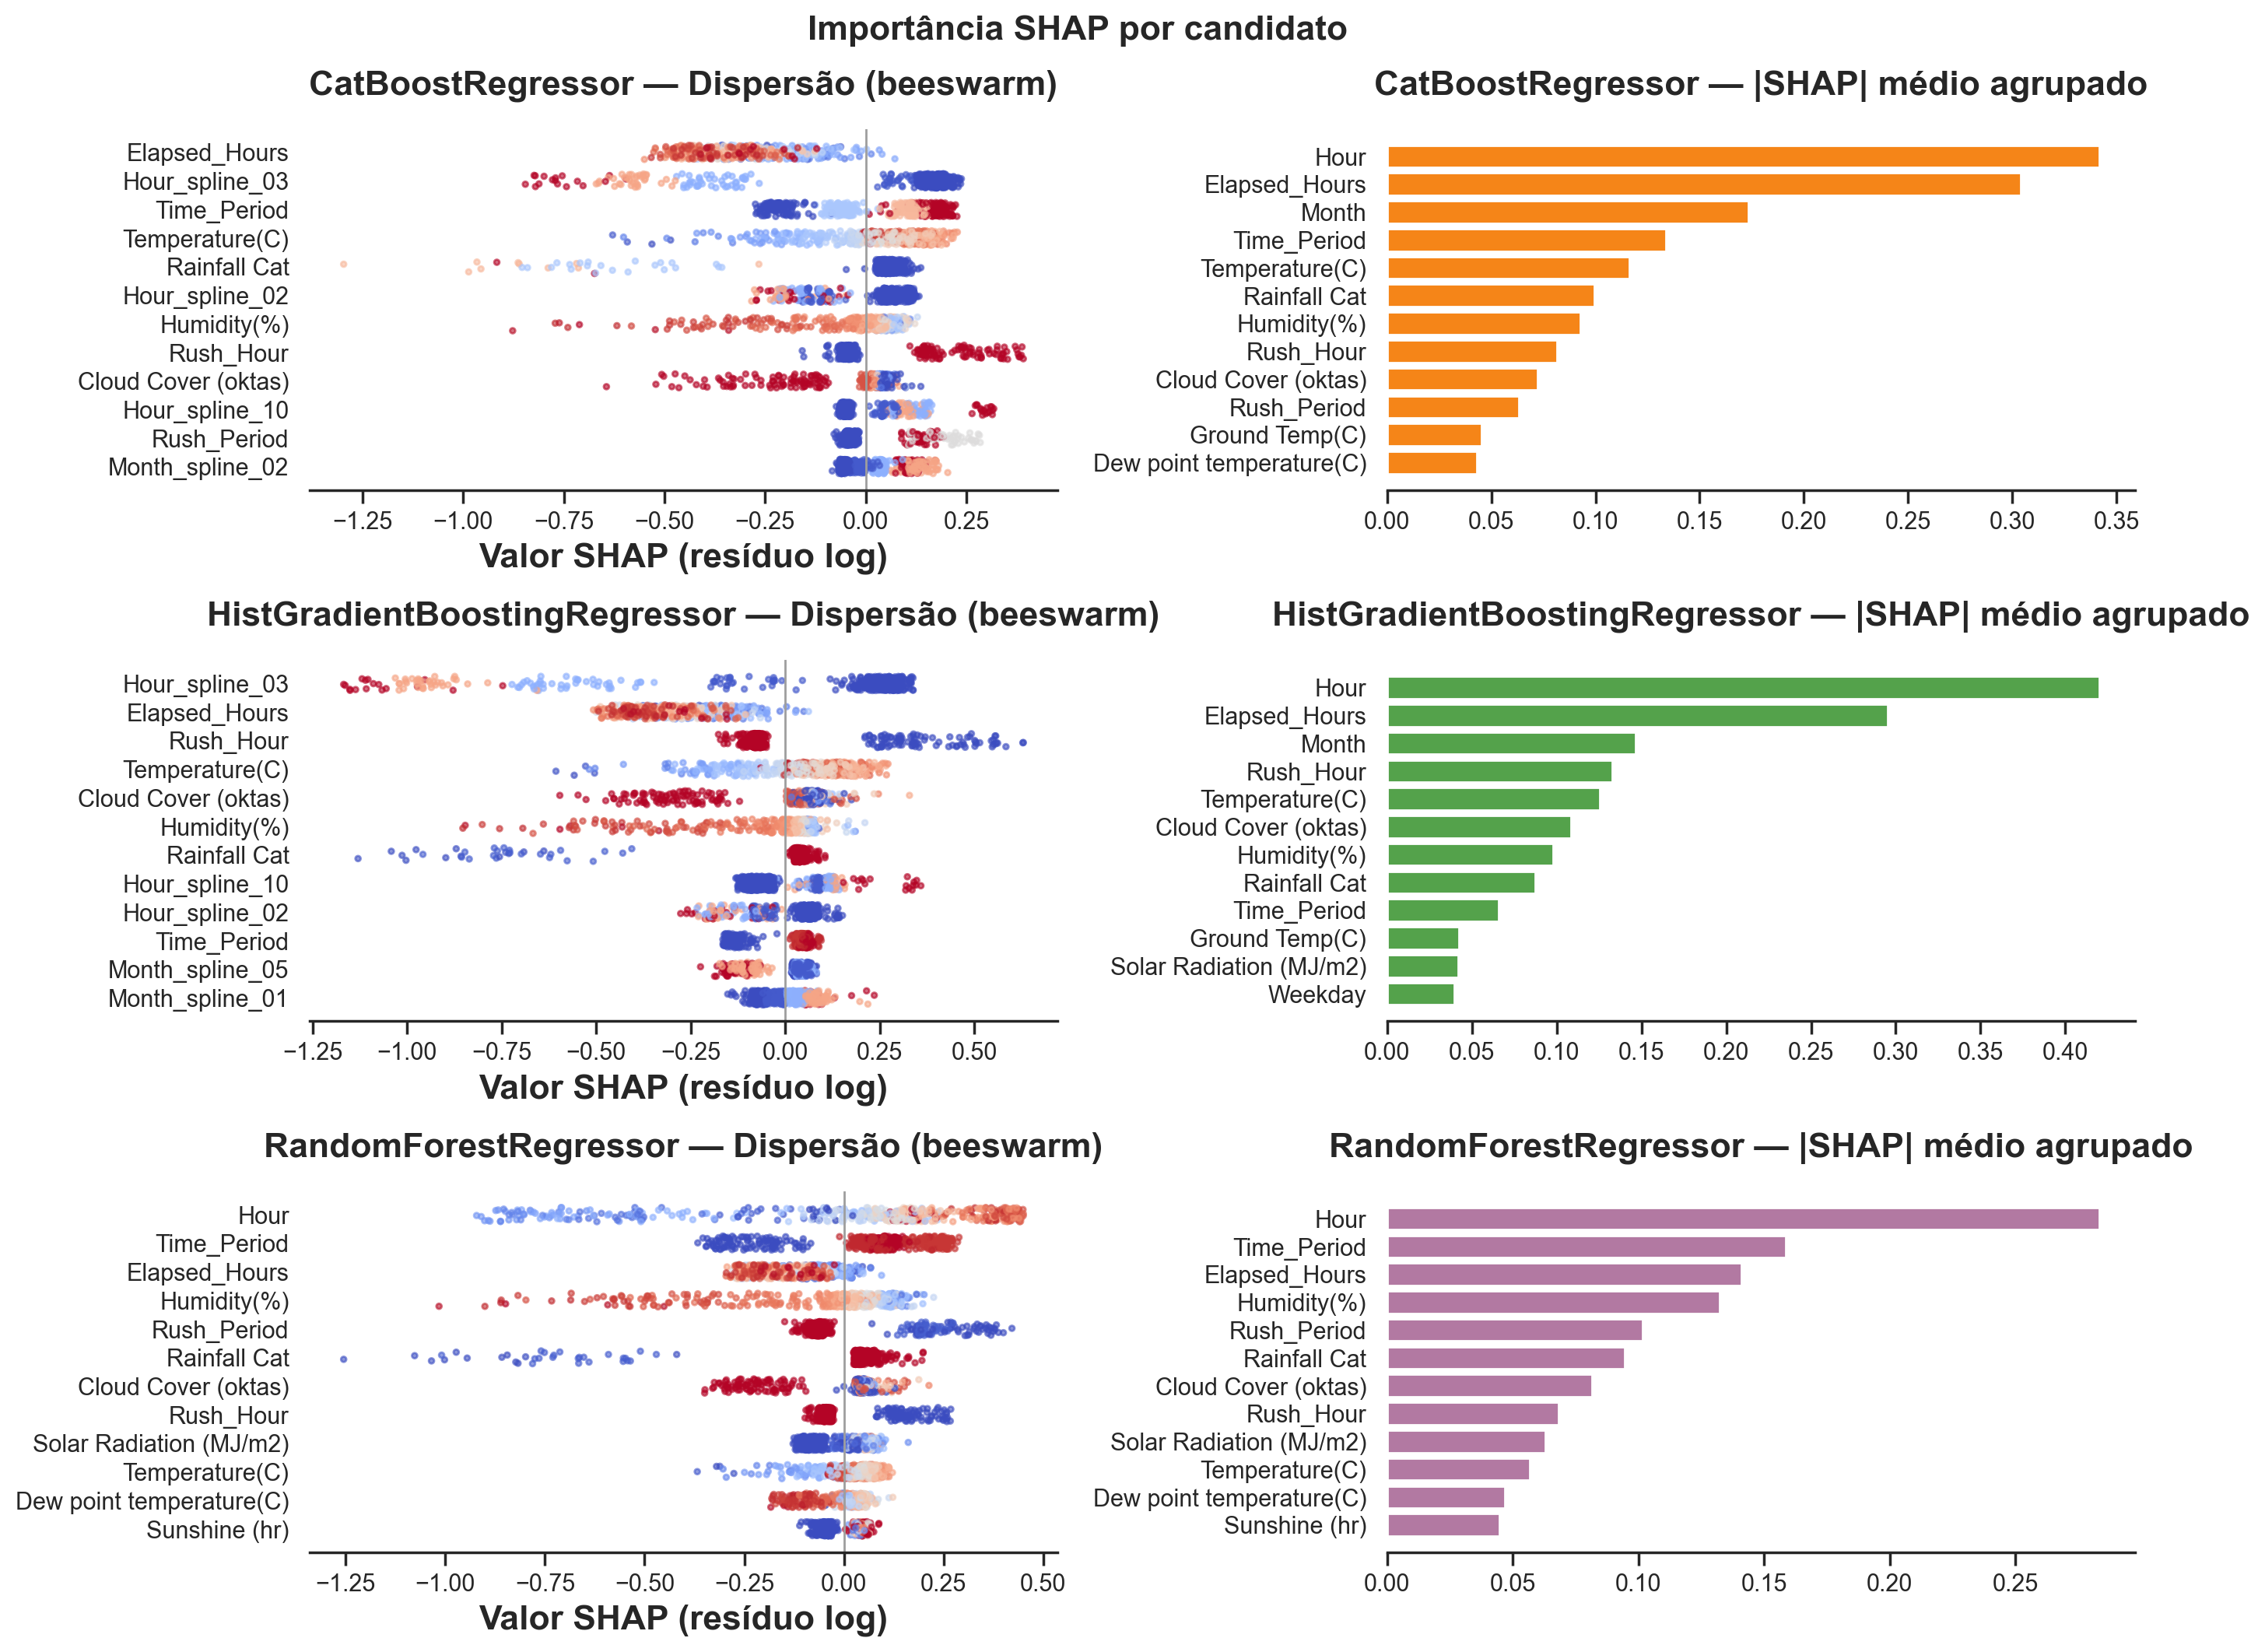

In [30]:
reports.plot_shap_summary(shap_results, lang=lang)

In [31]:
reports.shap_feature_comparison_report(shap_results, lang=lang)

,Feature conceitual,CatBoostRegressor,HistGradientBoostingRegressor,RandomForestRegressor
0,Cloud Cover (oktas),0.072296,0.108650,0.081562
1,Elapsed_Hours,0.304019,0.294967,0.140928
2,Hour,0.341607,0.419887,0.283376
3,Humidity(%),0.092603,0.097876,0.132214
4,Month,0.173192,0.146472,0.018465
5,Rainfall Cat,0.099444,0.087315,0.094667
6,Rush_Hour,0.081666,0.132615,0.068254
7,Rush_Period,0.063275,0.008852,0.101596
8,Temperature(C),0.116347,0.125238,0.056777
9,Time_Period,0.133843,0.065981,0.158741


## 11. Explicações SHAP locais

Além da amostra global, explicações locais são produzidas para o champion pré-registrado em uma
observação próxima do erro absoluto mediano, na maior subestimação e na maior superestimação. As
contribuições apresentadas são atribuições ao resíduo logarítmico, e não à demanda em bicicletas por
hora, conforme identificado no título dos gráficos.

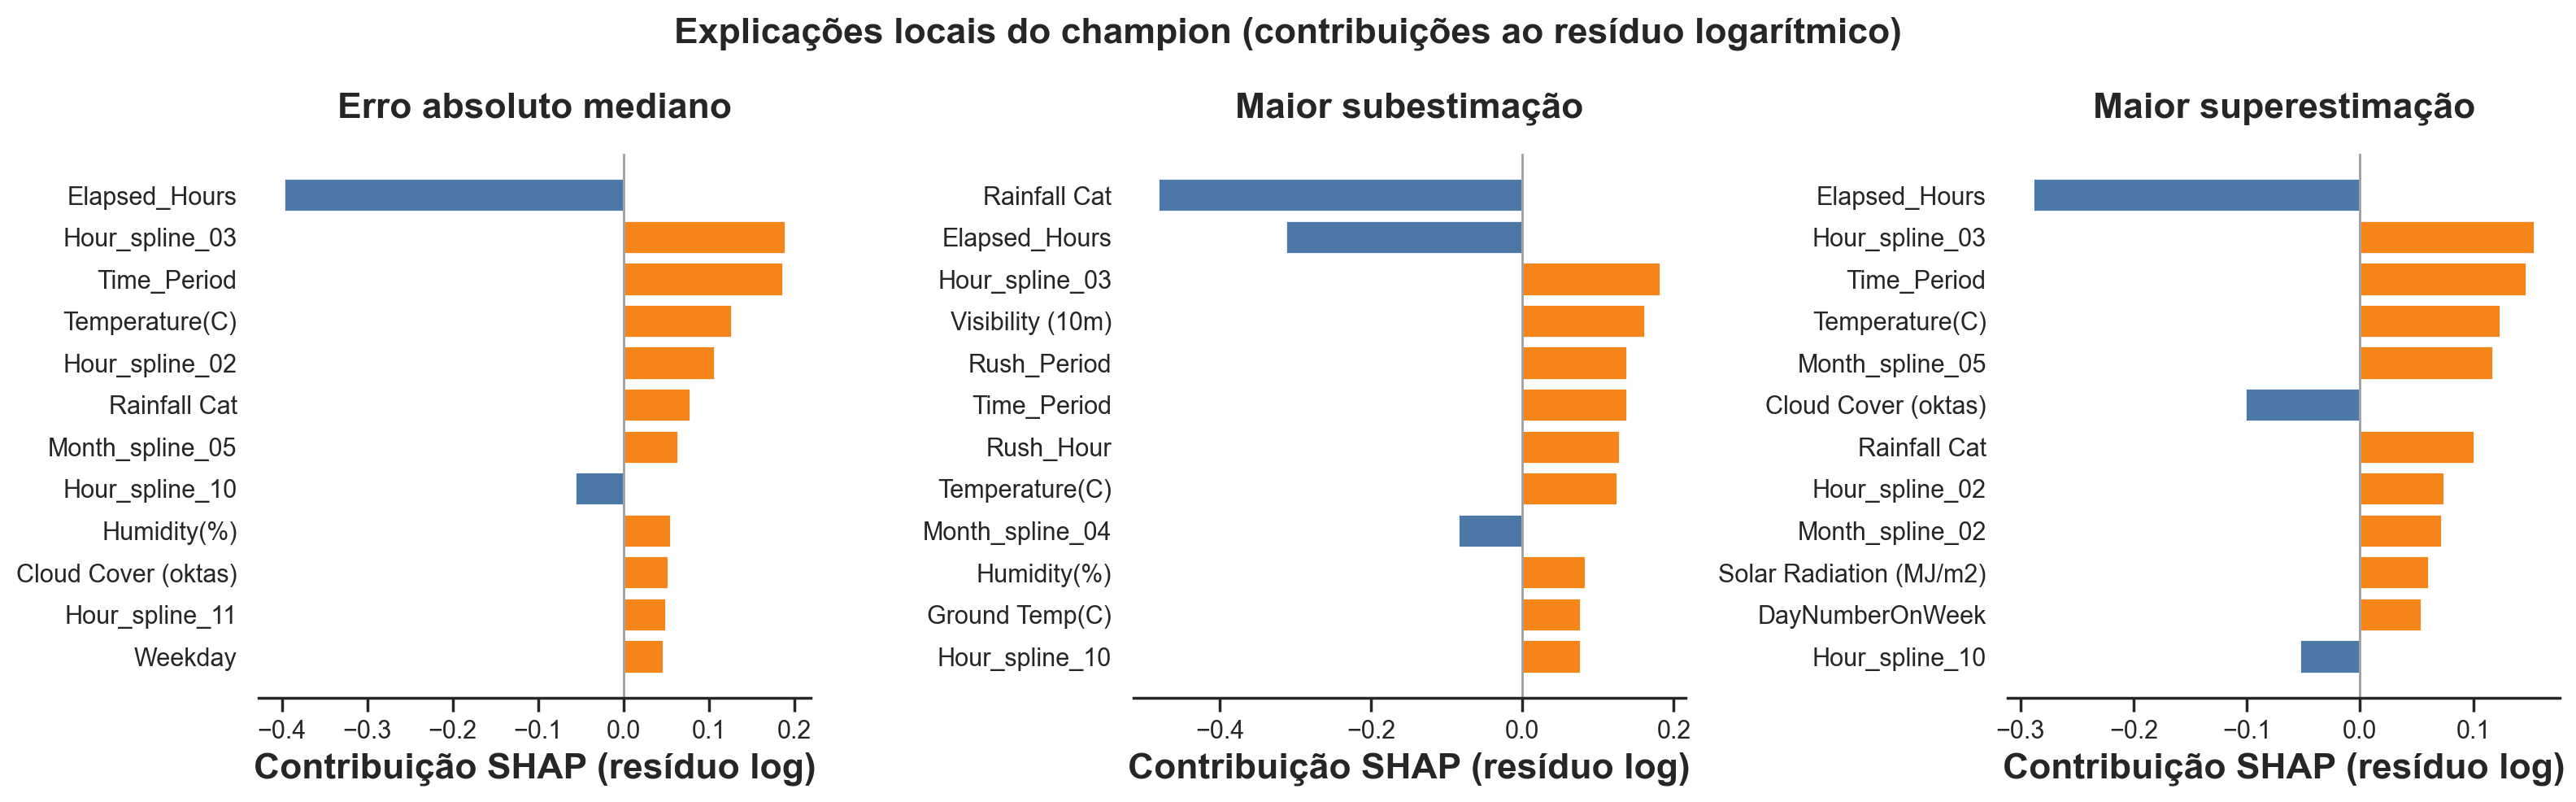

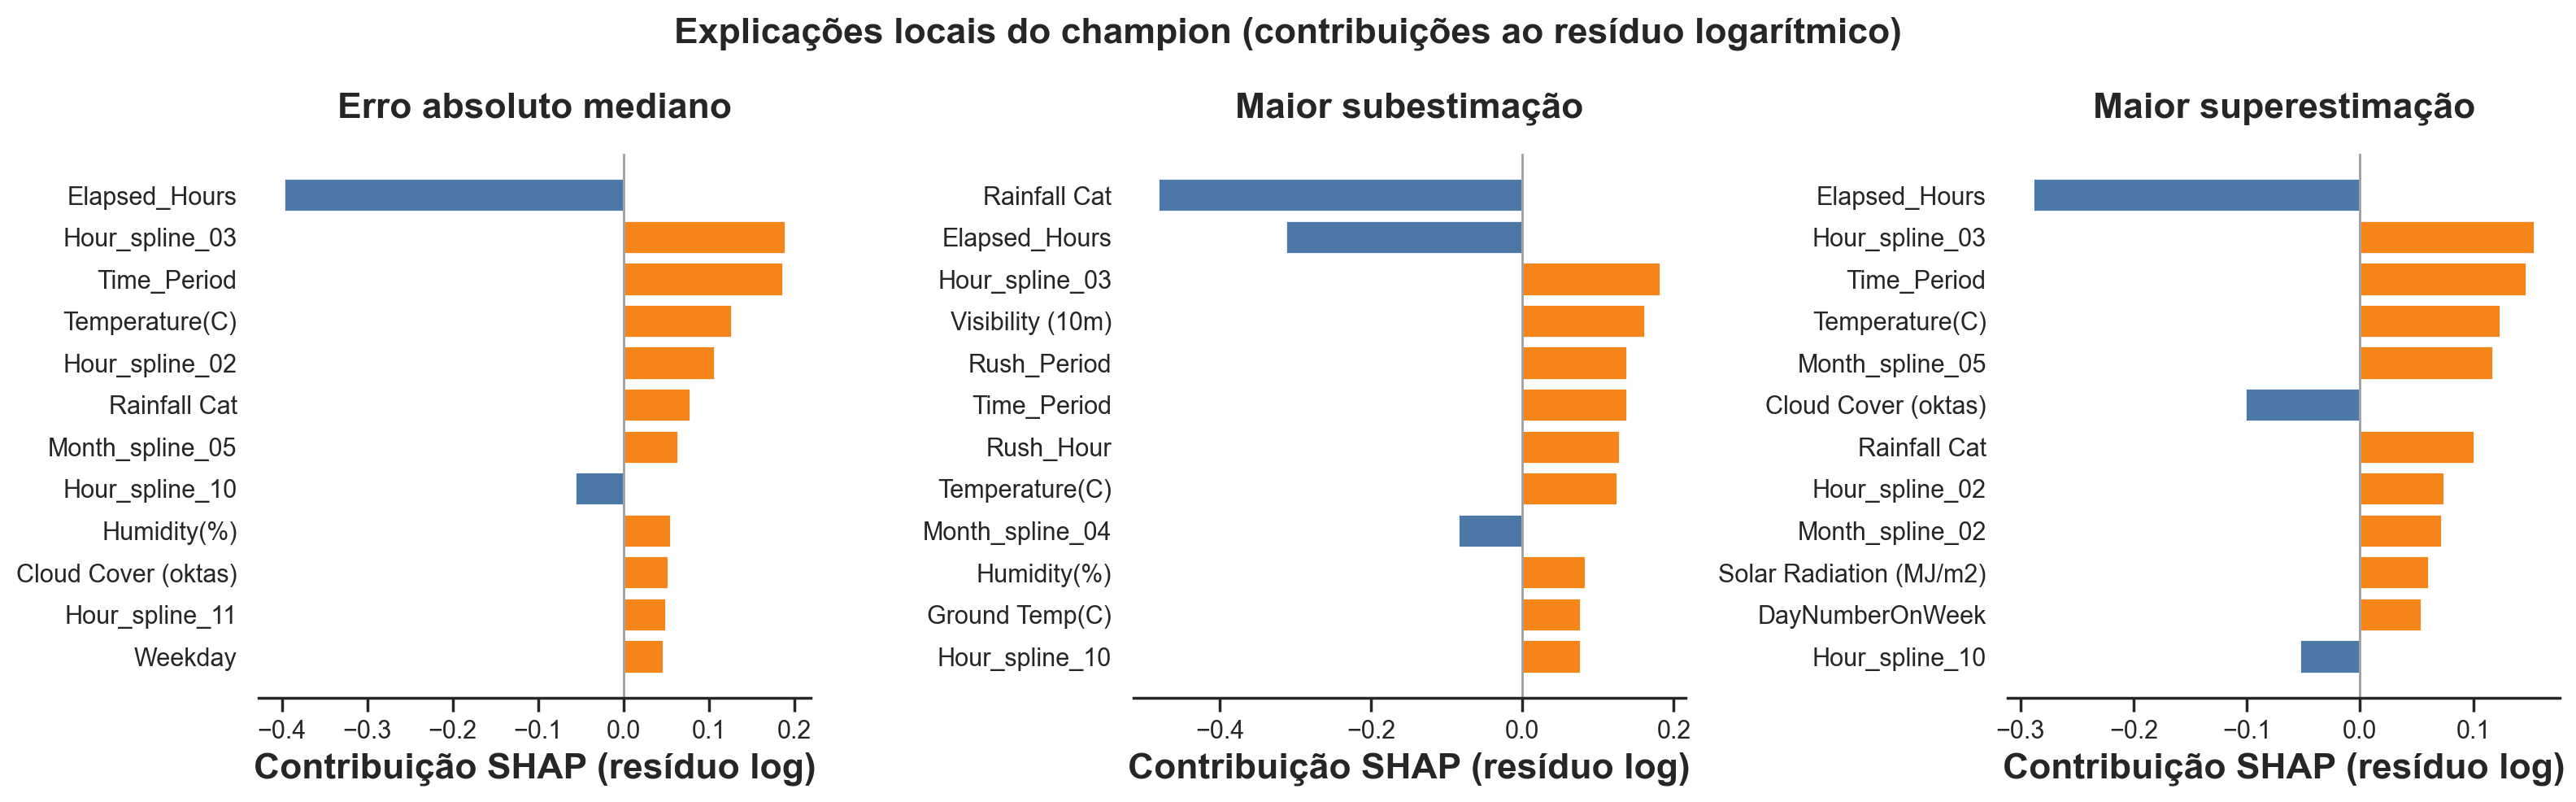

In [32]:
reports.plot_shap_local(results, shap_results, lang=lang)

## 12. Registro MLflow e artefatos finais

Os resultados são persistidos em um diretório de runtime próprio e registrados em um experimento
MLflow dedicado à validação final, com uma run pai e uma run filha por candidato. Os modelos não são
registrados novamente, pois os artefatos congelados já existem e são referenciados por identificador,
caminho e hash. As runs de seleção não são modificadas.

In [33]:
reports.artifacts_report(results, lang=lang)

,Item,Valor
0,Diretório de runtime,PROJECT_ROOT/...
1,Manifesto final,PROJECT_ROOT/...
2,Experimento MLflow,bike_sharing_demand_v4_final_validation
3,Run pai (MLflow),694315351bfe4b24b2df9ae098ecf7f5
4,Runs filhas (MLflow),"b886c7c303e34535808468465f6252ab, 1ad1a501b92f..."
5,Origem dos resultados,reutilizados do cache
6,Decisão registrada,Champion confirmado


## 13. Síntese

A síntese consolida a decisão confirmatória, a posição do Champion no holdout, a distância para o candidato mais próximo e as limitações residuais que foram observadas depois da validação final. A confirmação do CatBoost é preservada como decisão de previsão pontual; ao mesmo tempo, é registrado que o viés sistemático, a autocorrelação residual e a heterocedasticidade impedem que intervalos sob hipótese IID sejam tratados como validados.

A mensagem de handoff resume o desfecho e as suas limitações, preservando o manifesto do notebook 04 inalterado. Qualquer alteração futura no modelo deverá ser tratada como uma nova versão experimental, com backtesting no desenvolvimento e confirmação posterior em uma nova janela temporal independente.


In [34]:
reports.synthesis_report(results, lang=lang)

,Item,Valor
0,Decisão final,Champion confirmado
1,Champion,CatBoostRegressor
2,MAE do champion no holdout,1118.087
3,R² do champion no holdout,0.8393
4,Melhor no holdout,CatBoostRegressor
5,Diferença de MAE para o melhor,0.0
6,|bias| / MAE do champion,0.8945
7,Durbin-Watson residual,0.4072
8,Intervalos IID validados,False
9,Nova janela independente exigida,False


In [35]:
reports.handoff_message(results, lang=lang)

'A validação final confirma o champion pré-registrado sob o protocolo confirmatório, medido uma única vez no holdout temporal selado. Os resultados foram persistidos e registrados em experimento MLflow próprio, sem qualquer modificação nas runs de seleção. A triagem residual indica deslocamento predominante para superestimação; o |bias| representa 89.4% do MAE do champion. Após a retirada do padrão médio semanal, a autocorrelação no lag 168 foi reduzida em 41.7%; após a padronização por nível previsto, o indicador ARCH médio foi reduzido em 48.3%, mas a evidência de agrupamento condicional permaneceu. O CatBoost continua confirmado apenas como melhor previsão pontual sob o protocolo vigente; intervalos sob hipótese IID ainda não foram validados.'

### Referência metodológica

Breusch, T. S.; Pagan, A. R. (1979). A Simple Test for Heteroscedasticity and Random Coefficient Variation. Econometrica, 47(5), 1287-1294.

White, H. (1980). A Heteroskedasticity-Consistent Covariance Matrix Estimator and a Direct Test for Heteroskedasticity. Econometrica, 48(4), 817-838.

Goldfeld, S. M.; Quandt, R. E. (1965). Some Tests for Homoscedasticity. Journal of the American Statistical Association, 60(310), 539-547.

Engle, R. F. (1982). Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation. Econometrica, 50(4), 987-1007.

Lundberg, S. M.; Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. NeurIPS.

Lundberg, S. M. et al. (2020). From local explanations to global understanding with explainable AI for trees. Nature Machine Intelligence.
